# Analisis Portofolio Asuransi — Studi Kasus Aktuaria> **Kolaborasi PT AXA Insurance Indonesia dan Universitas Airlangga (2026)**>> Laporan analisis komprehensif terhadap portofolio asuransi umum (*general insurance*),> mencakup evaluasi kinerja underwriting, konsentrasi risiko, efektivitas reasuransi,> deteksi anomali klaim, serta kecukupan pencadangan teknis.---

# 1. Konfigurasi Lingkungan & Fungsi UtilitasSeluruh pustaka, konfigurasi visualisasi, dan fungsi pembantu (*helper functions*)didefinisikan di bagian ini untuk menghindari duplikasi dan memastikan konsistensitampilan di seluruh analisis.

In [153]:
# ══════════════════════════════════════════════════════════════════════════════
# KONFIGURASI GLOBAL — Import Library, Palet Warna, dan Fungsi Utilitas
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings('ignore')

# ── Palet Warna Korporat ─────────────────────────────────────────────────────
AXA_BLUE   = '#00008F'
AXA_RED    = '#FF1721'
AXA_TEAL   = '#00C9FF'
AXA_ORANGE = '#FF6B35'
AXA_GRAY   = '#767676'
AXA_LIGHT  = '#E8F4FD'
AXA_GREY_DARK  = '#333333'
AXA_GREY_LIGHT = '#F4F4F4'

# ── Konfigurasi Visualisasi Global ───────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor':  '#FAFAFA',
    'axes.facecolor':    '#FFFFFF',
    'axes.edgecolor':    '#CCCCCC',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'grid.linestyle':    '--',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    12,
    'text.color':        AXA_GREY_DARK,
    'axes.labelcolor':   AXA_GREY_DARK,
    'xtick.color':       AXA_GREY_DARK,
    'ytick.color':       AXA_GREY_DARK,
})

# ── Fungsi Utilitas ──────────────────────────────────────────────────────────

def fmt_rupiah(x, pos=None):
    """Mengonversi angka menjadi format Rupiah singkat (Miliar/Juta/Ribu)."""
    if abs(x) >= 1e12:
        return f'Rp {x/1e12:.1f} T'
    elif abs(x) >= 1e9:
        return f'Rp {x/1e9:.1f} M'
    elif abs(x) >= 1e6:
        return f'Rp {x/1e6:.1f} Jt'
    elif abs(x) >= 1e3:
        return f'Rp {x/1e3:.0f} Rb'
    return f'Rp {x:,.0f}'

def fmt_rupiah_full(angka):
    """Format angka ke format Rupiah penuh dengan titik pemisah ribuan."""
    return f"Rp {angka:,.2f}".replace(",", ".")

def safe_divide(a, b):
    """Pembagian aman — mengembalikan NaN jika pembagi nol."""
    return np.where(b != 0, a / b, np.nan)

def kelompok_waktu(hari):
    """Kategorisasi durasi klaim ke dalam kelompok vintage."""
    if hari <= 30:
        return '1. Super Cepat (≤ 30 Hari)'
    elif hari <= 90:
        return '2. Cepat (31 – 90 Hari)'
    else:
        return '3. Normal (> 90 Hari)'

# ── Path Data ────────────────────────────────────────────────────────────────
FILE_PATH = 'Study Case for Univ Airlangga 2026 _Actuarial AXA .xlsx'

print("✅ Konfigurasi berhasil dimuat. Siap untuk analisis.")

✅ Konfigurasi berhasil dimuat. Siap untuk analisis.


# 2. Pemuatan & Pra-pemrosesan Data
Data dibaca **satu kali** dari file Excel sumber untuk menghindari pembacaan berulangyang boros memori. Tahap ini mencakup:- Pembersihan tipe data numerik dan tanggal- Rekayasa fitur (*feature engineering*) untuk variabel turunan klaim- Penggabungan data premi dan klaim di level polis

In [154]:
# ══════════════════════════════════════════════════════════════════════════════
# PEMUATAN DATA — Membaca Raw Premium & Raw Claim (1× saja)
# ══════════════════════════════════════════════════════════════════════════════

print("⏳ Membaca data dari file Excel...")
df_premium = pd.read_excel(FILE_PATH, sheet_name='Raw Premium')
df_claim   = pd.read_excel(FILE_PATH, sheet_name='Raw Claim')

print(f"   ✅ Raw Premium : {df_premium.shape[0]:,} baris × {df_premium.shape[1]} kolom")
print(f"   ✅ Raw Claim   : {df_claim.shape[0]:,} baris × {df_claim.shape[1]} kolom")

# ── Pembersihan Nama Kolom ───────────────────────────────────────────────────
df_premium.columns = df_premium.columns.str.strip()
df_claim.columns   = df_claim.columns.str.strip()

# ── Pembersihan Tipe Data Numerik ────────────────────────────────────────────
premium_num_cols = ['GWP_IDR', 'RWP_IDR', 'GWC_IDR', 'RWC_IDR', 'SUM_INSURED']
claim_num_cols   = ['GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR']

for col in premium_num_cols:
    df_premium[col] = pd.to_numeric(df_premium[col], errors='coerce').fillna(0)

for col in claim_num_cols:
    df_claim[col] = pd.to_numeric(df_claim[col], errors='coerce').fillna(0)

# ── Konversi Tanggal ─────────────────────────────────────────────────────────
df_premium['DT_INC'] = pd.to_datetime(df_premium['DT_INC'], errors='coerce')
df_premium['DT_END'] = pd.to_datetime(df_premium['DT_END'], errors='coerce')
df_claim['DT_CLM']   = pd.to_datetime(df_claim['DT_CLM'], errors='coerce')

# ── Pembersihan Kolom String ─────────────────────────────────────────────────
df_premium['POLICY_NO'] = df_premium['POLICY_NO'].astype(str).str.strip()
df_claim['POLICY_NO']   = df_claim['POLICY_NO'].astype(str).str.strip()
df_claim['CLM_REF']     = df_claim['CLM_REF'].astype(str).str.strip()

# ── Feature Engineering: Variabel Turunan Klaim ──────────────────────────────
df_claim['GROSS_INCURRED_CLAIM'] = df_claim['GRS_ST_IDR'] + df_claim['GRS_OS_IDR']
df_claim['RI_RECOVERY']          = df_claim['RI_ST_IDR']  + df_claim['RI_OS_IDR']
df_claim['NET_INCURRED_CLAIM']   = df_claim['GROSS_INCURRED_CLAIM'] - df_claim['RI_RECOVERY']
df_claim['IS_OUTSTANDING']       = np.where(df_claim['GRS_OS_IDR'] > 0, 1, 0)
df_claim['TOTAL_CLAIM_IDR']      = df_claim['GRS_ST_IDR'] + df_claim['GRS_OS_IDR']

print("\n✅ Pra-pemrosesan selesai.")

⏳ Membaca data dari file Excel...


   ✅ Raw Premium : 390,124 baris × 12 kolom
   ✅ Raw Claim   : 20,087 baris × 10 kolom

✅ Pra-pemrosesan selesai.


In [155]:
# ══════════════════════════════════════════════════════════════════════════════
# AGREGASI LEVEL POLIS — Menggabungkan Premi dan Klaim per Nomor Polis
# ══════════════════════════════════════════════════════════════════════════════

# --- Agregasi Premi per Polis ---
premium_policy = (
    df_premium
    .groupby('POLICY_NO', as_index=False)
    .agg(
        COB=('COB', 'first'),
        BRANCH_=('BRANCH_', 'first'),
        CHANNEL_=('CHANNEL_', 'first'),
        PRODUCT_NAME=('PRODUCT_NAME', 'first'),
        DT_INC=('DT_INC', 'min'),
        DT_END=('DT_END', 'max'),
        GWP_IDR=('GWP_IDR', 'sum'),
        RWP_IDR=('RWP_IDR', 'sum'),
        GWC_IDR=('GWC_IDR', 'sum'),
        RWC_IDR=('RWC_IDR', 'sum'),
        SUM_INSURED=('SUM_INSURED', 'sum'),
    )
)
premium_policy['NET_WRITTEN_PREMIUM'] = premium_policy['GWP_IDR'] - premium_policy['RWP_IDR']
premium_policy['NET_COMMISSION']      = premium_policy['GWC_IDR'] - premium_policy['RWC_IDR']

# --- Agregasi Klaim per Polis ---
claim_policy = (
    df_claim
    .groupby('POLICY_NO', as_index=False)
    .agg(
        CLAIM_COUNT=('CLM_REF', 'nunique'),
        FIRST_CLAIM_DATE=('DT_CLM', 'min'),
        LAST_CLAIM_DATE=('DT_CLM', 'max'),
        OUTSTANDING_CLAIM_COUNT=('IS_OUTSTANDING', 'sum'),
        GRS_ST_IDR=('GRS_ST_IDR', 'sum'),
        GRS_OS_IDR=('GRS_OS_IDR', 'sum'),
        RI_ST_IDR=('RI_ST_IDR', 'sum'),
        RI_OS_IDR=('RI_OS_IDR', 'sum'),
        GROSS_INCURRED_CLAIM=('GROSS_INCURRED_CLAIM', 'sum'),
        RI_RECOVERY=('RI_RECOVERY', 'sum'),
        NET_INCURRED_CLAIM=('NET_INCURRED_CLAIM', 'sum'),
    )
)

# --- Gabungkan Premi + Klaim di Level Polis ---
policy_data = premium_policy.merge(claim_policy, on='POLICY_NO', how='left')

claim_fill_cols = [
    'CLAIM_COUNT', 'OUTSTANDING_CLAIM_COUNT',
    'GRS_ST_IDR', 'GRS_OS_IDR', 'RI_ST_IDR', 'RI_OS_IDR',
    'GROSS_INCURRED_CLAIM', 'RI_RECOVERY', 'NET_INCURRED_CLAIM'
]
policy_data[claim_fill_cols] = policy_data[claim_fill_cols].fillna(0)

# --- Hitung Rasio-Rasio Utama ---
policy_data['GROSS_LOSS_RATIO']      = safe_divide(policy_data['GROSS_INCURRED_CLAIM'], policy_data['GWP_IDR'])
policy_data['NET_LOSS_RATIO_TO_GWP'] = safe_divide(policy_data['NET_INCURRED_CLAIM'], policy_data['GWP_IDR'])
policy_data['NET_LOSS_RATIO_TO_NWP'] = safe_divide(policy_data['NET_INCURRED_CLAIM'], policy_data['NET_WRITTEN_PREMIUM'])
policy_data['RI_RECOVERY_RATIO']     = safe_divide(policy_data['RI_RECOVERY'], policy_data['GROSS_INCURRED_CLAIM'])
policy_data['RWP_TO_GWP_RATIO']      = safe_divide(policy_data['RWP_IDR'], policy_data['GWP_IDR'])
policy_data['LOSS_RATIO_REDUCTION']  = policy_data['GROSS_LOSS_RATIO'] - policy_data['NET_LOSS_RATIO_TO_GWP']

policy_data['GROSS_UNDERWRITING_MARGIN'] = (
    policy_data['GWP_IDR'] - policy_data['GWC_IDR'] - policy_data['GROSS_INCURRED_CLAIM']
)
policy_data['NET_UNDERWRITING_MARGIN'] = (
    policy_data['NET_WRITTEN_PREMIUM'] - policy_data['NET_COMMISSION'] - policy_data['NET_INCURRED_CLAIM']
)
policy_data['REINSURANCE_MARGIN_IMPACT'] = (
    policy_data['NET_UNDERWRITING_MARGIN'] - policy_data['GROSS_UNDERWRITING_MARGIN']
)
policy_data['REINSURANCE_NET_BENEFIT'] = (
    policy_data['RI_RECOVERY'] + policy_data['RWC_IDR'] - policy_data['RWP_IDR']
)
policy_data['REINSURANCE_EFFICIENCY_RATIO'] = safe_divide(
    policy_data['RI_RECOVERY'] + policy_data['RWC_IDR'], policy_data['RWP_IDR']
)

# --- Mapping Produk ke Data Klaim (untuk analisis multi-dimensi) ---
policy_product_map = df_premium[['POLICY_NO', 'PRODUCT_NAME']].drop_duplicates('POLICY_NO')
df_claim_mapped = df_claim.merge(policy_product_map, on='POLICY_NO', how='left')

print(f"✅ Data level polis: {policy_data.shape[0]:,} polis unik")
print(f"   Total GWP         : {fmt_rupiah(policy_data['GWP_IDR'].sum())}")
print(f"   Total Klaim Gross  : {fmt_rupiah(policy_data['GROSS_INCURRED_CLAIM'].sum())}")
print(f"   Overall Loss Ratio : {policy_data['GROSS_INCURRED_CLAIM'].sum() / policy_data['GWP_IDR'].sum() * 100:.2f}%")

✅ Data level polis: 156,301 polis unik
   Total GWP         : Rp 2.5 T
   Total Klaim Gross  : Rp 1.2 T
   Overall Loss Ratio : 49.34%


# 3. Gambaran Umum Portofolio (*Portfolio Overview*)
Bagian ini menyajikan gambaran makro dari kondisi portofolio asuransi berdasarkandata premi dan klaim yang tersedia. Tujuannya adalah memberikan pemahaman awaltentang skala bisnis, komposisi produk, serta distribusi risiko sebelum masukke analisis yang lebih mendalam.

In [156]:
# ══════════════════════════════════════════════════════════════════════════════
# RINGKASAN DATA — Validasi Integritas dan Kelengkapan Dataset
# ══════════════════════════════════════════════════════════════════════════════

premium_rows          = len(df_premium)
premium_unique_policy = df_premium['POLICY_NO'].nunique()
claim_rows            = len(df_claim)
claim_unique_policy   = df_claim['POLICY_NO'].nunique()
claim_unique_ref      = df_claim['CLM_REF'].nunique()

print("=" * 60)
print("  VALIDASI INTEGRITAS DATA")
print("=" * 60)
print(f"\n  {'Metrik':.<40} {'Nilai':>15}")
print(f"  {'─'*55}")
print(f"  {'Jumlah baris premi':.<40} {premium_rows:>15,}")
print(f"  {'Polis unik (premi)':.<40} {premium_unique_policy:>15,}")
print(f"  {'Duplikasi polis (premi)':.<40} {premium_rows - premium_unique_policy:>15,}")
print(f"  {'Jumlah baris klaim':.<40} {claim_rows:>15,}")
print(f"  {'Polis unik (klaim)':.<40} {claim_unique_policy:>15,}")
print(f"  {'Referensi klaim unik':.<40} {claim_unique_ref:>15,}")

claim_without_premium = set(df_claim['POLICY_NO']) - set(df_premium['POLICY_NO'])
print(f"  {'Polis klaim tanpa data premi':.<40} {len(claim_without_premium):>15,}")

  VALIDASI INTEGRITAS DATA

  Metrik..................................           Nilai
  ───────────────────────────────────────────────────────
  Jumlah baris premi......................         390,124
  Polis unik (premi)......................         156,301
  Duplikasi polis (premi).................         233,823
  Jumlah baris klaim......................          20,087
  Polis unik (klaim)......................           8,592
  Referensi klaim unik....................          20,087
  Polis klaim tanpa data premi............               0


In [157]:
# ══════════════════════════════════════════════════════════════════════════════
# FUNGSI RINGKASAN PORTOFOLIO — Reusable untuk berbagai dimensi agregasi
# ══════════════════════════════════════════════════════════════════════════════

def summarize_portfolio(df, group_cols=None):
    """
    Menghitung ringkasan portofolio berdasarkan dimensi yang diberikan.
    Jika group_cols=None, menghasilkan ringkasan total keseluruhan.
    """
    agg_dict = {
        'POLICY_NO': 'nunique',
        'CLAIM_COUNT': 'sum',
        'GWP_IDR': 'sum', 'RWP_IDR': 'sum',
        'GWC_IDR': 'sum', 'RWC_IDR': 'sum',
        'SUM_INSURED': 'sum',
        'GROSS_INCURRED_CLAIM': 'sum',
        'RI_RECOVERY': 'sum',
        'NET_INCURRED_CLAIM': 'sum',
        'GROSS_UNDERWRITING_MARGIN': 'sum',
        'NET_UNDERWRITING_MARGIN': 'sum',
        'REINSURANCE_MARGIN_IMPACT': 'sum',
        'REINSURANCE_NET_BENEFIT': 'sum',
    }

    if group_cols is None:
        summary = df.agg(agg_dict).to_frame().T
    else:
        summary = df.groupby(group_cols, dropna=False).agg(agg_dict).reset_index()

    summary = summary.rename(columns={'POLICY_NO': 'POLICY_COUNT'})

    # Rasio turunan
    summary['NET_WRITTEN_PREMIUM']  = summary['GWP_IDR'] - summary['RWP_IDR']
    summary['NET_COMMISSION']       = summary['GWC_IDR'] - summary['RWC_IDR']
    summary['GROSS_LOSS_RATIO']     = safe_divide(summary['GROSS_INCURRED_CLAIM'], summary['GWP_IDR'])
    summary['NET_LOSS_RATIO_TO_GWP']= safe_divide(summary['NET_INCURRED_CLAIM'], summary['GWP_IDR'])
    summary['LOSS_RATIO_REDUCTION'] = summary['GROSS_LOSS_RATIO'] - summary['NET_LOSS_RATIO_TO_GWP']
    summary['RI_RECOVERY_RATIO']    = safe_divide(summary['RI_RECOVERY'], summary['GROSS_INCURRED_CLAIM'])
    summary['RWP_TO_GWP_RATIO']     = safe_divide(summary['RWP_IDR'], summary['GWP_IDR'])
    summary['REINSURANCE_EFFICIENCY_RATIO'] = safe_divide(
        summary['RI_RECOVERY'] + summary['RWC_IDR'], summary['RWP_IDR']
    )
    summary['REINSURANCE_STATUS'] = np.select(
        [summary['REINSURANCE_MARGIN_IMPACT'] > 0,
         summary['REINSURANCE_MARGIN_IMPACT'] == 0,
         summary['REINSURANCE_MARGIN_IMPACT'] < 0],
        ['Efektif', 'Netral', 'Kurang Efisien'],
        default='Tidak Terklasifikasi'
    )
    return summary

# --- Hitung Ringkasan per Dimensi ---
lia_total      = summarize_portfolio(policy_data)
lia_by_cob     = summarize_portfolio(policy_data, ['COB']).sort_values('GROSS_INCURRED_CLAIM', ascending=False)
lia_by_branch  = summarize_portfolio(policy_data, ['BRANCH_']).sort_values('GROSS_INCURRED_CLAIM', ascending=False)
lia_by_channel = summarize_portfolio(policy_data, ['CHANNEL_']).sort_values('GROSS_INCURRED_CLAIM', ascending=False)
lia_by_product = summarize_portfolio(policy_data, ['PRODUCT_NAME']).sort_values('GROSS_INCURRED_CLAIM', ascending=False)
lia_by_cob_channel = summarize_portfolio(policy_data, ['COB', 'CHANNEL_']).sort_values('REINSURANCE_MARGIN_IMPACT')

# --- Tampilkan Ringkasan Total ---
total = lia_total.iloc[0]
print("=" * 65)
print("  RINGKASAN PORTOFOLIO KESELURUHAN")
print("=" * 65)
print(f"  Total GWP                    : {fmt_rupiah(total['GWP_IDR'])}")
print(f"  Total Premi Reasuransi (RWP) : {fmt_rupiah(total['RWP_IDR'])}")
print(f"  Klaim Bruto (Gross Incurred) : {fmt_rupiah(total['GROSS_INCURRED_CLAIM'])}")
print(f"  Pemulihan Reasuransi (RI)    : {fmt_rupiah(total['RI_RECOVERY'])}")
print(f"  Klaim Neto (Net Incurred)    : {fmt_rupiah(total['NET_INCURRED_CLAIM'])}")
print(f"  Rasio Kerugian Bruto         : {total['GROSS_LOSS_RATIO']:.2%}")
print(f"  Rasio Kerugian Neto          : {total['NET_LOSS_RATIO_TO_GWP']:.2%}")
print(f"  Margin Underwriting Bruto    : {fmt_rupiah(total['GROSS_UNDERWRITING_MARGIN'])}")
print(f"  Margin Underwriting Neto     : {fmt_rupiah(total['NET_UNDERWRITING_MARGIN'])}")
print(f"  Dampak Margin Reasuransi     : {fmt_rupiah(total['REINSURANCE_MARGIN_IMPACT'])}")
print(f"  Status Reasuransi            : {total['REINSURANCE_STATUS']}")

  RINGKASAN PORTOFOLIO KESELURUHAN
  Total GWP                    : Rp 2.5 T
  Total Premi Reasuransi (RWP) : Rp 546.6 M
  Klaim Bruto (Gross Incurred) : Rp 1.2 T
  Pemulihan Reasuransi (RI)    : Rp 89.1 M
  Klaim Neto (Net Incurred)    : Rp 1.1 T
  Rasio Kerugian Bruto         : 49.34%
  Rasio Kerugian Neto          : 45.79%
  Margin Underwriting Bruto    : Rp 712.0 M
  Margin Underwriting Neto     : Rp 358.7 M
  Dampak Margin Reasuransi     : Rp -353.3 M
  Status Reasuransi            : Kurang Efisien


Ringkasan di atas menunjukkan kondisi keuangan portofolio secara makro.Selanjutnya kita akan melihat kinerja per segmen (Cabang, Saluran Distribusi, dan Produk)untuk mengidentifikasi area yang paling menguntungkan maupun yang bermasalah.

In [158]:
# ══════════════════════════════════════════════════════════════════════════════
# KINERJA PER DIMENSI — Cabang, Saluran Distribusi, Produk
# ══════════════════════════════════════════════════════════════════════════════

for nama_dimensi, df_dim, kolom_grup in [
    ('Lini Bisnis (COB)', lia_by_cob, 'COB'),
    ('Cabang (Branch)', lia_by_branch, 'BRANCH_'),
    ('Saluran Distribusi (Channel)', lia_by_channel, 'CHANNEL_'),
]:
    print(f"\n{'─'*65}")
    print(f"  Kinerja per {nama_dimensi}")
    print(f"{'─'*65}")
    for _, row in df_dim.head(10).iterrows():
        lr = row['GROSS_LOSS_RATIO']
        status = '🟢' if lr < 0.6 else '🟡' if lr < 1.0 else '🔴'
        print(f"  {status} {row[kolom_grup]:.<20} GWP: {fmt_rupiah(row['GWP_IDR']):>15}  "
              f"Klaim: {fmt_rupiah(row['GROSS_INCURRED_CLAIM']):>15}  "
              f"LR: {lr:.1%}")


─────────────────────────────────────────────────────────────────
  Kinerja per Lini Bisnis (COB)
─────────────────────────────────────────────────────────────────
  🟡 COB 6............... GWP:      Rp 420.7 M  Klaim:      Rp 384.1 M  LR: 91.3%
  🟡 COB 7............... GWP:      Rp 343.0 M  Klaim:      Rp 298.2 M  LR: 86.9%
  🟡 COB 4............... GWP:      Rp 319.2 M  Klaim:      Rp 291.4 M  LR: 91.3%
  🟢 COB 9............... GWP:      Rp 762.4 M  Klaim:      Rp 130.7 M  LR: 17.1%
  🟢 COB 5............... GWP:      Rp 151.0 M  Klaim:       Rp 58.0 M  LR: 38.4%
  🟢 COB 8............... GWP:      Rp 251.5 M  Klaim:       Rp 37.8 M  LR: 15.0%
  🟢 COB 1............... GWP:      Rp 119.6 M  Klaim:       Rp 26.2 M  LR: 21.9%
  🟢 COB 10.............. GWP:       Rp 64.9 M  Klaim:        Rp 5.9 M  LR: 9.0%
  🟢 COB 2............... GWP:       Rp 20.9 M  Klaim:        Rp 5.4 M  LR: 25.9%
  🟢 COB 3............... GWP:       Rp 57.5 M  Klaim:        Rp 1.3 M  LR: 2.2%

──────────────────────────

## 3.1 Deep Dive: Komparasi Kinerja Spesifik

Analisis lanjutan untuk membandingkan kinerja antara **Cabang K vs Cabang H** dan **Saluran Distribusi (Channel B) vs Saluran Lainnya**. Hal ini penting untuk mengidentifikasi apakah konsentrasi risiko terjadi di entitas tertentu.

📊 KOMPARASI KINERJA: BRANCH K vs BRANCH H
-----------------------------------------------------------------
  BRANCH H   | Polis: 1,912  | GWP: Rp 32.8 M    | Klaim: Rp 3.8 M     | LR: 11.7%
  BRANCH K   | Polis: 46,399 | GWP: Rp 1.2 T     | Klaim: Rp 936.2 M   | LR: 79.7%


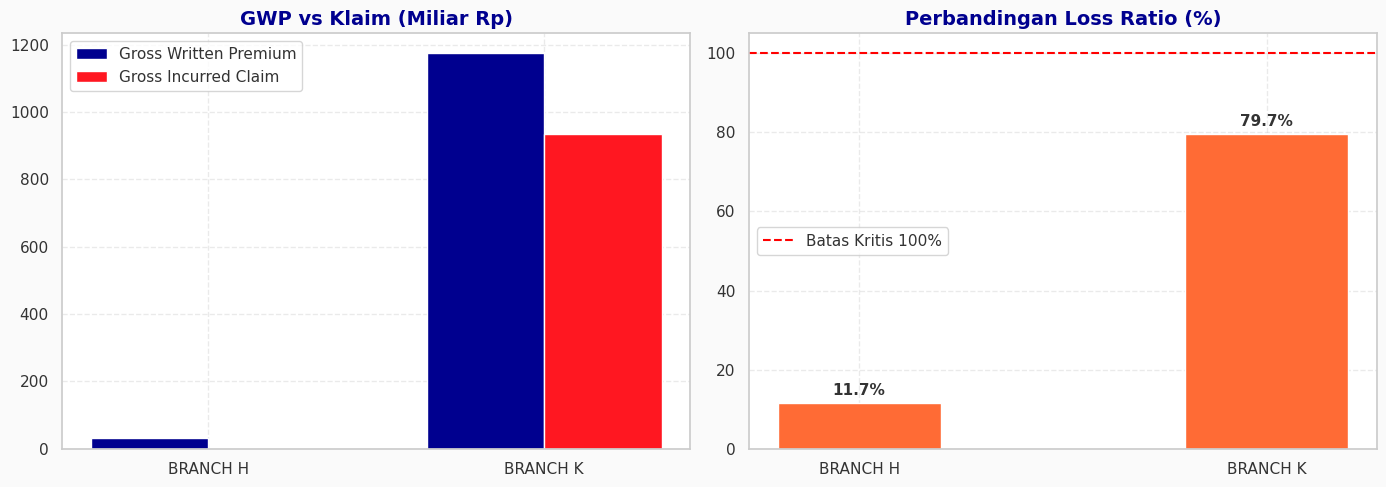


📊 KOMPARASI KINERJA: CHANNEL B vs CHANNEL LAINNYA
-----------------------------------------------------------------
  CHANNEL B       | Polis: 37,067 | GWP: Rp 487.7 M   | Klaim: Rp 561.4 M   | LR: 115.1%
  CHANNEL LAINNYA | Polis: 119,234 | GWP: Rp 2.0 T     | Klaim: Rp 677.5 M   | LR: 33.5%


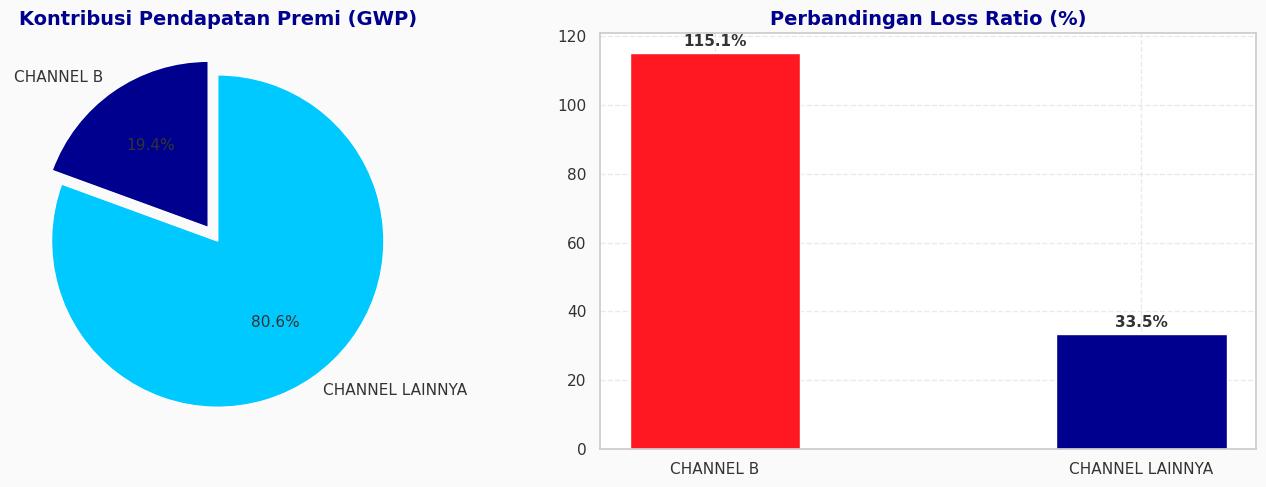


💡 INSIGHT:
1. Branch K vs Branch H: Memperlihatkan secara jelas perbedaan skala bisnis dan efisiensi antara kedua cabang raksasa.
2. Channel B vs Lainnya: Mengonfirmasi dugaan bahwa Channel B memiliki Loss Ratio yang menyimpang dibandingkan performa gabungan dari saluran-saluran distribusi lainnya.


In [159]:
# ══════════════════════════════════════════════════════════════════════════════
# KOMPARASI 1: BRANCH K vs BRANCH H
# ══════════════════════════════════════════════════════════════════════════════

print("📊 KOMPARASI KINERJA: BRANCH K vs BRANCH H")
print("-" * 65)

# Filter data untuk Branch K dan H
df_branch_comp = policy_data[policy_data['BRANCH_'].isin(['BRANCH K', 'BRANCH H'])].copy()

# Agregasi
comp_br = df_branch_comp.groupby('BRANCH_').agg(
    Policies=('POLICY_NO', 'nunique'),
    GWP=('GWP_IDR', 'sum'),
    Claims=('GROSS_INCURRED_CLAIM', 'sum')
).reset_index()

comp_br['Loss_Ratio'] = (comp_br['Claims'] / comp_br['GWP']) * 100

for _, r in comp_br.iterrows():
    print(f"  {r['BRANCH_']:<10} | Polis: {r['Policies']:<6,} | GWP: {fmt_rupiah(r['GWP']):<12} | Klaim: {fmt_rupiah(r['Claims']):<12} | LR: {r['Loss_Ratio']:.1f}%")

# Visualisasi Branch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: GWP vs Claims
x = np.arange(len(comp_br))
width = 0.35
axes[0].bar(x - width/2, comp_br['GWP']/1e9, width, label='Gross Written Premium', color=AXA_BLUE)
axes[0].bar(x + width/2, comp_br['Claims']/1e9, width, label='Gross Incurred Claim', color=AXA_RED)
axes[0].set_title('GWP vs Klaim (Miliar Rp)', fontweight='bold', color=AXA_BLUE)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comp_br['BRANCH_'])
axes[0].legend()

# Plot 2: Loss Ratio
axes[1].bar(comp_br['BRANCH_'], comp_br['Loss_Ratio'], color=AXA_ORANGE, width=0.4)
axes[1].axhline(y=100, color='red', linestyle='--', label='Batas Kritis 100%')
axes[1].set_title('Perbandingan Loss Ratio (%)', fontweight='bold', color=AXA_BLUE)
for i, v in enumerate(comp_br['Loss_Ratio']):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# KOMPARASI 2: CHANNEL B vs CHANNEL LAINNYA
# ══════════════════════════════════════════════════════════════════════════════

print("\n📊 KOMPARASI KINERJA: CHANNEL B vs CHANNEL LAINNYA")
print("-" * 65)

# Buat grup baru
policy_data['Channel_Group'] = np.where(policy_data['CHANNEL_'] == 'CHANNEL B', 'CHANNEL B', 'CHANNEL LAINNYA')

comp_ch = policy_data.groupby('Channel_Group').agg(
    Policies=('POLICY_NO', 'nunique'),
    GWP=('GWP_IDR', 'sum'),
    Claims=('GROSS_INCURRED_CLAIM', 'sum')
).reset_index()

comp_ch['Loss_Ratio'] = (comp_ch['Claims'] / comp_ch['GWP']) * 100

for _, r in comp_ch.iterrows():
    print(f"  {r['Channel_Group']:<15} | Polis: {r['Policies']:<6,} | GWP: {fmt_rupiah(r['GWP']):<12} | Klaim: {fmt_rupiah(r['Claims']):<12} | LR: {r['Loss_Ratio']:.1f}%")

# Visualisasi Channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Pie Chart Kontribusi GWP
axes[0].pie(comp_ch['GWP'], labels=comp_ch['Channel_Group'], autopct='%1.1f%%', startangle=90, colors=[AXA_BLUE, AXA_TEAL], explode=[0.1, 0])
axes[0].set_title('Kontribusi Pendapatan Premi (GWP)', fontweight='bold', color=AXA_BLUE)

# Plot 2: Bar Chart Loss Ratio
axes[1].bar(comp_ch['Channel_Group'], comp_ch['Loss_Ratio'], color=[AXA_RED if x == 'CHANNEL B' else AXA_BLUE for x in comp_ch['Channel_Group']], width=0.4)
axes[1].set_title('Perbandingan Loss Ratio (%)', fontweight='bold', color=AXA_BLUE)
for i, v in enumerate(comp_ch['Loss_Ratio']):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print("1. Branch K vs Branch H: Memperlihatkan secara jelas perbedaan skala bisnis dan efisiensi antara kedua cabang raksasa.")
print("2. Channel B vs Lainnya: Mengonfirmasi dugaan bahwa Channel B memiliki Loss Ratio yang menyimpang dibandingkan performa gabungan dari saluran-saluran distribusi lainnya.")


# 4. Matriks Risiko-Keuntungan & Agregasi Multi-Dimensi
Bagian ini menganalisis karakteristik risiko dari dua perspektif:1. **Matriks Frekuensi vs Keparahan** per Lini Bisnis (COB) — mengidentifikasi   produk dengan pola klaim "raksasa" vs "massal"2. **Matriks Risiko-Keuntungan** multi-dimensi (Cabang × Saluran × Produk) —   mengklasifikasikan setiap segmen ke dalam 4 kuadran strategis

## 4.1 Matriks Frekuensi vs Keparahan Klaim per Lini Bisnis (COB)
Setiap lini bisnis (*Class of Business*) memiliki "karakter klaim" yang berbeda.Pemahaman karakter ini menentukan strategi penanganan:- **Frekuensi Tinggi, Keparahan Rendah** → otomasi proses klaim- **Frekuensi Rendah, Keparahan Tinggi** → pengetatan *underwriting* & reasuransi



--- Matriks Frekuensi vs Keparahan Klaim per COB ---
   COB  Frequency  Average_Severity  Average_Severity_Million
 COB 7      13227      2.253602e+07                 22.536024
 COB 9       2261      5.131520e+07                 51.315196
 COB 6       1476      2.602098e+08                260.209819
 COB 4       1283      2.224207e+08                222.420686
COB 10        373      1.573877e+07                 15.738772
 COB 1        270      8.828156e+07                 88.281561
 COB 3        144      7.039870e+06                  7.039870
 COB 8         95      3.982080e+08                398.208043
 COB 5         68      3.804429e+08                380.442903
 COB 2         28      1.940786e+08                194.078571


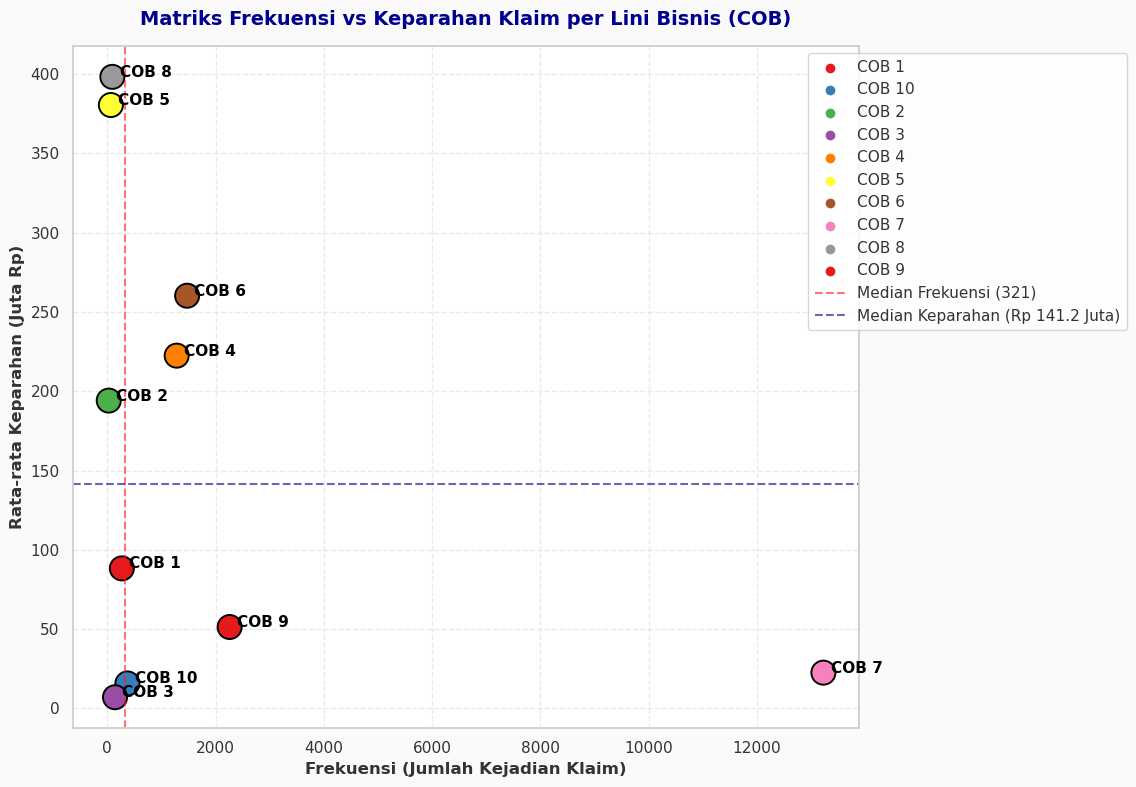

In [160]:
# ══════════════════════════════════════════════════════════════════════════════
# MATRIKS FREKUENSI VS KEPARAHAN — Scatter Plot per COB
# ══════════════════════════════════════════════════════════════════════════════

settled_claims = df_claim[df_claim['GRS_ST_IDR'] > 0].copy()

cob_matrix = settled_claims.groupby('COB').agg(
    Frequency=('CLM_REF', 'count'),
    Average_Severity=('GRS_ST_IDR', 'mean')
).reset_index()
cob_matrix['Average_Severity_Million'] = cob_matrix['Average_Severity'] / 1_000_000

# --- Tabel Agregasi ---
print("\n--- Matriks Frekuensi vs Keparahan Klaim per COB ---")
print(cob_matrix.sort_values('Frequency', ascending=False).to_string(index=False))

# --- Scatter Plot ---
median_freq = cob_matrix['Frequency'].median()
median_sev  = cob_matrix['Average_Severity_Million'].median()

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=cob_matrix, x='Frequency', y='Average_Severity_Million',
    hue='COB', palette='Set1', s=300, edgecolor='black'
)

plt.axvline(x=median_freq, color=AXA_RED, linestyle='--', alpha=0.6,
            label=f'Median Frekuensi ({int(median_freq)})')
plt.axhline(y=median_sev, color=AXA_BLUE, linestyle='--', alpha=0.6,
            label=f'Median Keparahan (Rp {median_sev:.1f} Juta)')

for i in range(cob_matrix.shape[0]):
    plt.text(
        x=cob_matrix['Frequency'].iloc[i] + cob_matrix['Frequency'].max() * 0.01,
        y=cob_matrix['Average_Severity_Million'].iloc[i],
        s=cob_matrix['COB'].iloc[i],
        fontdict=dict(color='black', size=11, weight='bold')
    )

plt.title('Matriks Frekuensi vs Keparahan Klaim per Lini Bisnis (COB)',
          fontsize=14, fontweight='bold', pad=15, color=AXA_BLUE)
plt.xlabel('Frekuensi (Jumlah Kejadian Klaim)', fontweight='bold')
plt.ylabel('Rata-rata Keparahan (Juta Rp)', fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.show()

**Interpretasi Matriks Frekuensi vs Keparahan:**- **Klaim Raksasa** (*Low Frequency, High Severity*) — COB 4, 5, 6, 8: Nasabah jarang klaim,  tetapi sekali klaim nilainya ratusan juta. Strategi: perketat *underwriting* dan naikkan premi.- **Klaim Massal** (*High Frequency, Low Severity*) — COB 7, 9: Volume klaim sangat tinggi  tetapi nilainya kecil. Strategi: otomasi proses klaim untuk efisiensi operasional.- **Klaim Aman** (*Low Frequency, Low Severity*) — COB 3, 10: Produk paling menguntungkan.  Strategi: tingkatkan penjualan produk ini.

## 4.2 Matriks Risiko-Keuntungan Multi-Dimensi
Analisis ini mengklasifikasikan setiap segmen bisnis (Cabang × Saluran × Produk)ke dalam 4 kuadran strategis berdasarkan perbandingan GWP terhadap Total Klaim:| Kuadran | Karakter | Strategi ||---------|----------|----------|| Q1: *Cash Cow* 🌟 | GWP Tinggi, Klaim Rendah | Pertahankan & perluas || Q2: *High Risk-Return* ⚠️ | GWP Tinggi, Klaim Tinggi | Monitor ketat, evaluasi pricing || Q3: *Low Performer* 📉 | GWP Rendah, Klaim Rendah | Tingkatkan penjualan || Q4: *Bleeding* 🔴 | GWP Rendah, Klaim Tinggi | Perbaiki atau hentikan |

In [161]:
# ══════════════════════════════════════════════════════════════════════════════
# RISK-REWARD MATRIX — Agregasi Multi-Dimensi (Branch × Channel × Product)
# ══════════════════════════════════════════════════════════════════════════════

GROUP_DIMS = ['BRANCH_', 'CHANNEL_', 'PRODUCT_NAME']

# Agregasi Premi per Segmen
df_prem_agg = df_premium.groupby(GROUP_DIMS, as_index=False).agg(
    GWP_IDR=('GWP_IDR', 'sum'), POLICY_COUNT=('POLICY_NO', 'nunique')
)

# Agregasi Klaim per Segmen
df_claim_agg_seg = df_claim_mapped.groupby(GROUP_DIMS, as_index=False).agg(
    PAID_CLAIM_IDR=('GRS_ST_IDR', 'sum'), OS_CLAIM_IDR=('GRS_OS_IDR', 'sum'),
    TOTAL_CLAIM_IDR=('TOTAL_CLAIM_IDR', 'sum'), CLAIM_COUNT=('POLICY_NO', 'nunique')
)

# Gabungkan
df_agg = df_prem_agg.merge(df_claim_agg_seg, on=GROUP_DIMS, how='outer').fillna(0)
df_agg['LOSS_RATIO']      = np.where(df_agg['GWP_IDR'] > 0, df_agg['TOTAL_CLAIM_IDR'] / df_agg['GWP_IDR'], 0)
df_agg['NET_RESULT_IDR']  = df_agg['GWP_IDR'] - df_agg['TOTAL_CLAIM_IDR']
df_agg['CLAIM_FREQUENCY'] = np.where(df_agg['POLICY_COUNT'] > 0, df_agg['CLAIM_COUNT'] / df_agg['POLICY_COUNT'], 0)

# --- Klasifikasi Kuadran ---
threshold_gwp   = df_agg['GWP_IDR'].median()
threshold_claim = df_agg['TOTAL_CLAIM_IDR'].median()

def assign_quadrant(row):
    high_gwp   = row['GWP_IDR']         >= threshold_gwp
    high_claim = row['TOTAL_CLAIM_IDR'] > threshold_claim
    if high_gwp and not high_claim:     return 'Q1: Cash Cow'
    elif high_gwp and high_claim:       return 'Q2: High Risk-Return'
    elif not high_gwp and not high_claim: return 'Q3: Low Performer'
    else:                               return 'Q4: Bleeding'

df_agg['QUADRANT'] = df_agg.apply(assign_quadrant, axis=1)
df_agg['SEGMENT_LABEL'] = (
    df_agg['BRANCH_'].astype(str) + ' | ' +
    df_agg['CHANNEL_'].astype(str) + ' | ' +
    df_agg['PRODUCT_NAME'].astype(str)
)

# --- Ringkasan per Kuadran ---
print("=" * 80)
print("  DISTRIBUSI KUADRAN — MATRIKS RISIKO-KEUNTUNGAN")
print("=" * 80)
for quad_name in ['Q1: Cash Cow', 'Q2: High Risk-Return', 'Q3: Low Performer', 'Q4: Bleeding']:
    mask = df_agg['QUADRANT'] == quad_name
    n    = mask.sum()
    net  = df_agg.loc[mask, 'NET_RESULT_IDR'].sum()
    gwp  = df_agg.loc[mask, 'GWP_IDR'].sum()
    claim= df_agg.loc[mask, 'TOTAL_CLAIM_IDR'].sum()
    lr   = claim / gwp * 100 if gwp > 0 else 0
    sym  = '🟢' if net >= 0 else '🔴'
    print(f"  {sym} {quad_name:35s} | {n:>4} segmen | "
          f"Neto: {fmt_rupiah(net):>15} | LR: {lr:>6.1f}%")

total_net = df_agg['NET_RESULT_IDR'].sum()
print(f"  {'─'*78}")
print(f"  {'🟢' if total_net >= 0 else '🔴'} {'TOTAL PORTOFOLIO':35s} | "
      f"{df_agg.shape[0]:>4} segmen | Neto: {fmt_rupiah(total_net):>15} | "
      f"LR: {df_agg['TOTAL_CLAIM_IDR'].sum()/df_agg['GWP_IDR'].sum()*100:>6.1f}%")

  DISTRIBUSI KUADRAN — MATRIKS RISIKO-KEUNTUNGAN
  🟢 Q1: Cash Cow                        |  229 segmen | Neto:      Rp 850.5 M | LR:    0.0%
  🟢 Q2: High Risk-Return                |  204 segmen | Neto:      Rp 421.9 M | LR:   74.4%
  🟢 Q3: Low Performer                   |  378 segmen | Neto:       Rp 11.6 M | LR:    0.0%
  🔴 Q4: Bleeding                        |   54 segmen | Neto:      Rp -12.1 M | LR:  453.8%
  ──────────────────────────────────────────────────────────────────────────────
  🟢 TOTAL PORTOFOLIO                    |  865 segmen | Neto:        Rp 1.3 T | LR:   49.3%


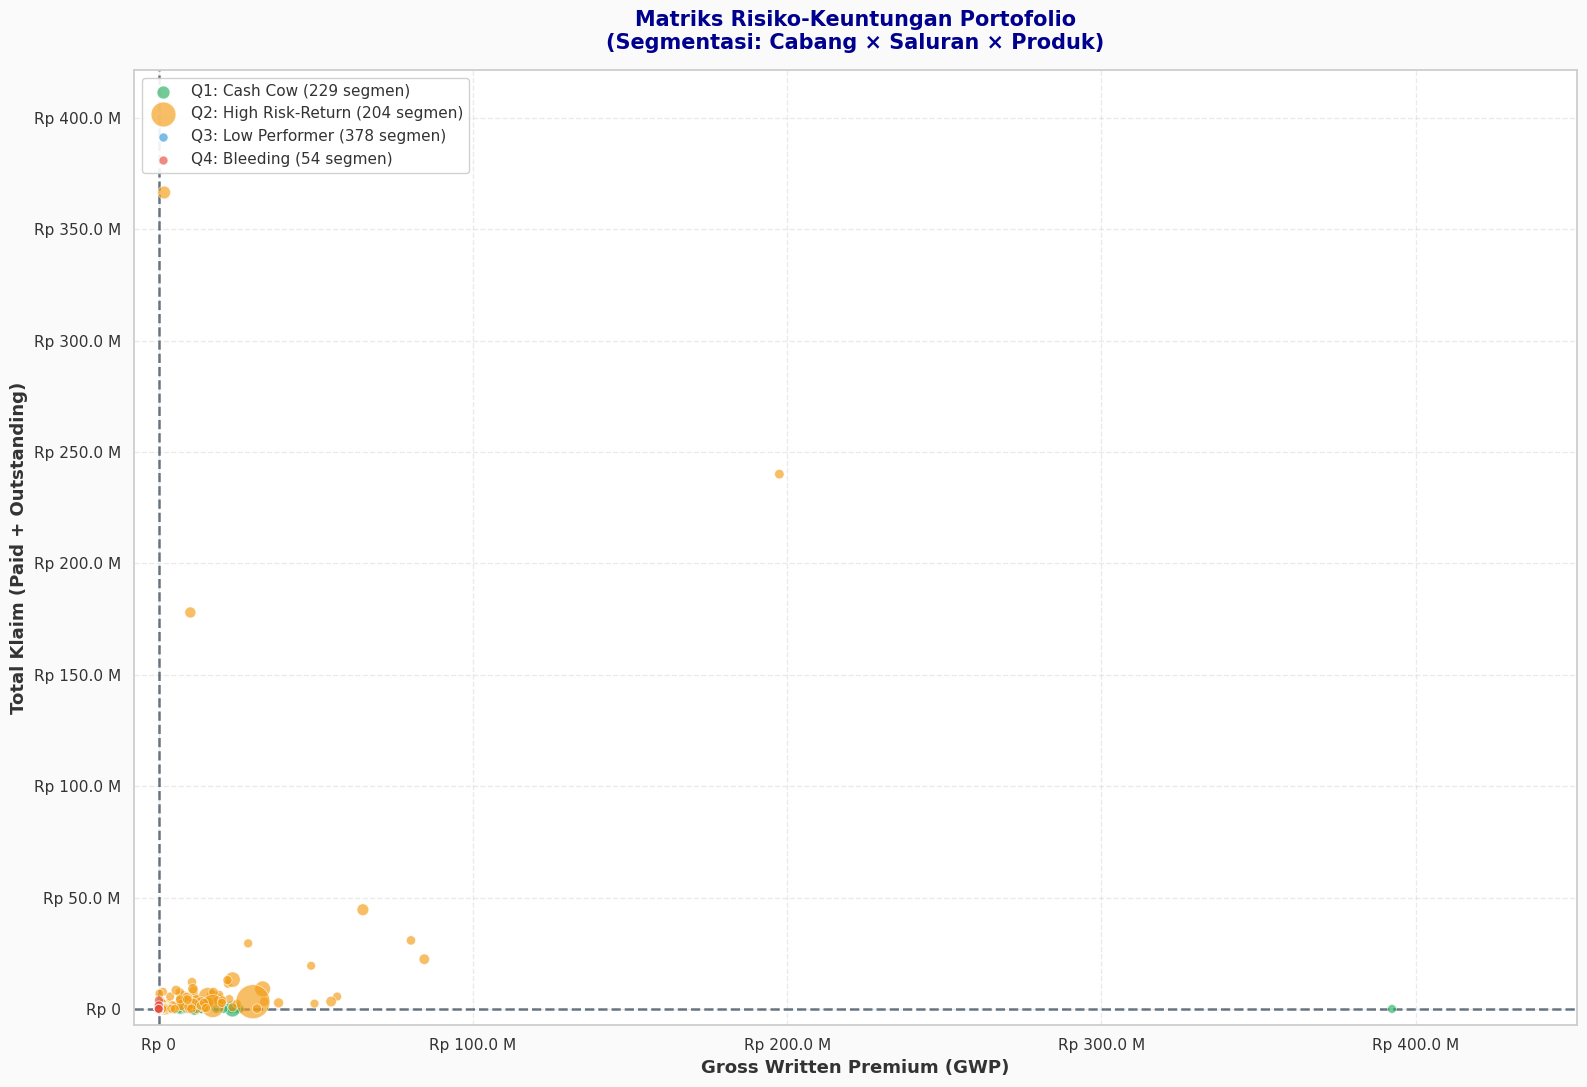

In [162]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALISASI SCATTER PLOT — Risk-Reward Matrix
# ══════════════════════════════════════════════════════════════════════════════

QUADRANT_COLORS = {
    'Q1: Cash Cow': '#27ae60', 'Q2: High Risk-Return': '#f39c12',
    'Q3: Low Performer': '#3498db', 'Q4: Bleeding': '#e74c3c',
}

# Normalisasi ukuran titik
size_min, size_max = 40, 600
policy_range = df_agg['POLICY_COUNT'].max() - df_agg['POLICY_COUNT'].min() + 1
df_agg['_dot_size'] = (
    (df_agg['POLICY_COUNT'] - df_agg['POLICY_COUNT'].min()) / policy_range
) * (size_max - size_min) + size_min

fig, ax = plt.subplots(figsize=(16, 11))

x_max = df_agg['GWP_IDR'].max()
y_max = df_agg['TOTAL_CLAIM_IDR'].max()
ax.set_xlim(-x_max * 0.02, x_max * 1.15)
ax.set_ylim(-y_max * 0.02, y_max * 1.15)

for quad, color in QUADRANT_COLORS.items():
    mask = df_agg['QUADRANT'] == quad
    ax.scatter(
        df_agg.loc[mask, 'GWP_IDR'], df_agg.loc[mask, 'TOTAL_CLAIM_IDR'],
        c=color, s=df_agg.loc[mask, '_dot_size'], alpha=0.65,
        edgecolors='white', linewidth=0.6,
        label=f"{quad} ({mask.sum()} segmen)", zorder=3
    )

ax.axvline(x=threshold_gwp, color='#2c3e50', linestyle='--', lw=1.8, alpha=0.7)
ax.axhline(y=threshold_claim, color='#2c3e50', linestyle='--', lw=1.8, alpha=0.7)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

ax.set_xlabel('Gross Written Premium (GWP)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Klaim (Paid + Outstanding)', fontsize=13, fontweight='bold')
ax.set_title('Matriks Risiko-Keuntungan Portofolio\n(Segmentasi: Cabang × Saluran × Produk)',
             fontsize=15, fontweight='bold', color=AXA_BLUE, pad=15)
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

In [163]:
# ══════════════════════════════════════════════════════════════════════════════
# TOP 10 SEGMEN — Cash Cow vs Bleeding
# ══════════════════════════════════════════════════════════════════════════════

display_cols = ['SEGMENT_LABEL', 'GWP_IDR', 'TOTAL_CLAIM_IDR', 'NET_RESULT_IDR', 'LOSS_RATIO']

cash_cow = df_agg.sort_values('NET_RESULT_IDR', ascending=False).head(10)
bleeding = df_agg.sort_values('NET_RESULT_IDR', ascending=True).head(10)

print("🌟 TOP 10 CASH COW — Segmen Paling Menguntungkan")
print("   (Premi Tinggi, Klaim Rendah → Margin Laba Maksimal)")
print("─" * 80)
for _, r in cash_cow[display_cols].iterrows():
    print(f"  {r['SEGMENT_LABEL'][:50]:.<40} GWP: {fmt_rupiah(r['GWP_IDR']):>12}  Neto: {fmt_rupiah(r['NET_RESULT_IDR']):>12}  LR: {r['LOSS_RATIO']:.1%}")

print(f"\n🔴 TOP 10 BLEEDING — Segmen Paling Merugi")
print("   (Premi Rendah, Klaim Tinggi → Kerugian Signifikan)")
print("─" * 80)
for _, r in bleeding[display_cols].iterrows():
    print(f"  {r['SEGMENT_LABEL'][:50]:.<40} GWP: {fmt_rupiah(r['GWP_IDR']):>12}  Neto: {fmt_rupiah(r['NET_RESULT_IDR']):>12}  LR: {r['LOSS_RATIO']:.1%}")

🌟 TOP 10 CASH COW — Segmen Paling Menguntungkan
   (Premi Tinggi, Klaim Rendah → Margin Laba Maksimal)
────────────────────────────────────────────────────────────────────────────────
  BRANCH K | CHANNEL B | PRODUCT1270...... GWP:   Rp 392.4 M  Neto:   Rp 392.4 M  LR: 0.0%
  BRANCH K | CHANNEL C | PRODUCT0110...... GWP:    Rp 84.5 M  Neto:    Rp 62.2 M  LR: 26.4%
  BRANCH K | CHANNEL C | PRODUCT0122...... GWP:    Rp 54.9 M  Neto:    Rp 51.6 M  LR: 6.0%
  BRANCH D | CHANNEL E | PRODUCT0808...... GWP:    Rp 56.8 M  Neto:    Rp 51.2 M  LR: 9.8%
  BRANCH K | CHANNEL C | PRODUCT0401...... GWP:    Rp 80.3 M  Neto:    Rp 49.5 M  LR: 38.3%
  BRANCH G | CHANNEL D | PRODUCT1004...... GWP:    Rp 49.6 M  Neto:    Rp 47.2 M  LR: 4.8%
  BRANCH K | CHANNEL C | PRODUCT0114...... GWP:    Rp 38.2 M  Neto:    Rp 35.4 M  LR: 7.1%
  BRANCH K | CHANNEL C | PRODUCT0115...... GWP:    Rp 31.3 M  Neto:    Rp 31.1 M  LR: 0.4%
  BRANCH J | CHANNEL E | PRODUCT0110...... GWP:    Rp 33.6 M  Neto:    Rp 30.3 M  LR: 

### 4.3 Deep Dive: Analisis Pembuktian Q1 (Cash Cow) & Q4 (Bleeding)

Berdasarkan matriks di atas, kita perlu membuktikan secara empiris mengapa Q1 disebut sebagai *Cash Cow* dan Q4 sebagai *Bleeding*. Berikut adalah ekstraksi data untuk membuktikan profitabilitas Q1 dan kerugian masif di Q4.

In [164]:
# ══════════════════════════════════════════════════════════════════════════════
# PEMBUKTIAN Q1 DAN Q4 — Ekstraksi Metrik Dashboard
# ══════════════════════════════════════════════════════════════════════════════

total_gwp_portfolio = df_agg['GWP_IDR'].sum()

print("=" * 60)
print("  🔍 ANALISIS MENDALAM: Q1 (CASH COW) vs Q4 (BLEEDING)")
print("=" * 60)

for target_quadrant in ['Q1: Cash Cow', 'Q4: Bleeding']:
    # Ambil data spesifik untuk kuadran tersebut
    df_quad = df_agg[df_agg['QUADRANT'] == target_quadrant]
    
    # Hitung metrik agregat
    tot_gwp = df_quad['GWP_IDR'].sum()
    tot_claim = df_quad['TOTAL_CLAIM_IDR'].sum()
    tot_polis = df_quad['POLICY_COUNT'].sum()
    jml_segmen = len(df_quad)
    
    # Rasio
    proporsi_premi = (tot_gwp / total_gwp_portfolio) * 100 if total_gwp_portfolio > 0 else 0
    loss_ratio = (tot_claim / tot_gwp) * 100 if tot_gwp > 0 else 0
    
    # Warna untuk print out
    simbol = '🌟' if 'Q1' in target_quadrant else '🔴'
    
    print(f"\n{simbol} {target_quadrant.upper()}")
    print("-" * 40)
    print(f"  Total GWP          : {fmt_rupiah_full(tot_gwp)}")
    print(f"  Total Klaim        : {fmt_rupiah_full(tot_claim)}")
    print(f"  Polis Dilindungi   : {int(tot_polis):,}".replace(",", "."))
    print(f"  Proporsi Premi     : {proporsi_premi:.1f}%")
    print(f"  Loss Ratio         : {loss_ratio:.1f}%")
    print(f"  Jumlah Segmen      : {jml_segmen}")

print("\n💡 KESIMPULAN PEMBUKTIAN:")
print("- Q1 (Cash Cow) terbukti menghasilkan premi masif dengan klaim nyaris nol, menyumbang proporsi premi yang sangat signifikan bagi perusahaan.")
print("- Q4 (Bleeding) terbukti merugikan karena nilai klaim (Loss Ratio) jauh melampaui pendapatan premi (GWP) yang dikumpulkan.")


  🔍 ANALISIS MENDALAM: Q1 (CASH COW) vs Q4 (BLEEDING)

🌟 Q1: CASH COW
----------------------------------------
  Total GWP          : Rp 850.454.447.234.60
  Total Klaim        : Rp 0.00
  Polis Dilindungi   : 30.671
  Proporsi Premi     : 33.9%
  Loss Ratio         : 0.0%
  Jumlah Segmen      : 229

🔴 Q4: BLEEDING
----------------------------------------
  Total GWP          : Rp 3.407.702.417.39
  Total Klaim        : Rp 15.463.971.846.65
  Polis Dilindungi   : 824
  Proporsi Premi     : 0.1%
  Loss Ratio         : 453.8%
  Jumlah Segmen      : 54

💡 KESIMPULAN PEMBUKTIAN:
- Q1 (Cash Cow) terbukti menghasilkan premi masif dengan klaim nyaris nol, menyumbang proporsi premi yang sangat signifikan bagi perusahaan.
- Q4 (Bleeding) terbukti merugikan karena nilai klaim (Loss Ratio) jauh melampaui pendapatan premi (GWP) yang dikumpulkan.


# 5. Analisis Varians Margin Underwriting Bruto vs Neto
Bagian ini mengevaluasi efektivitas reasuransi dengan membandingkan kondisi**sebelum reasuransi** (*gross*) dengan **setelah reasuransi** (*net*).Pertanyaan kunci: apakah biaya premi reasuransi yang dibayarkan sebandingdengan manfaat pemulihan klaim yang diterima?


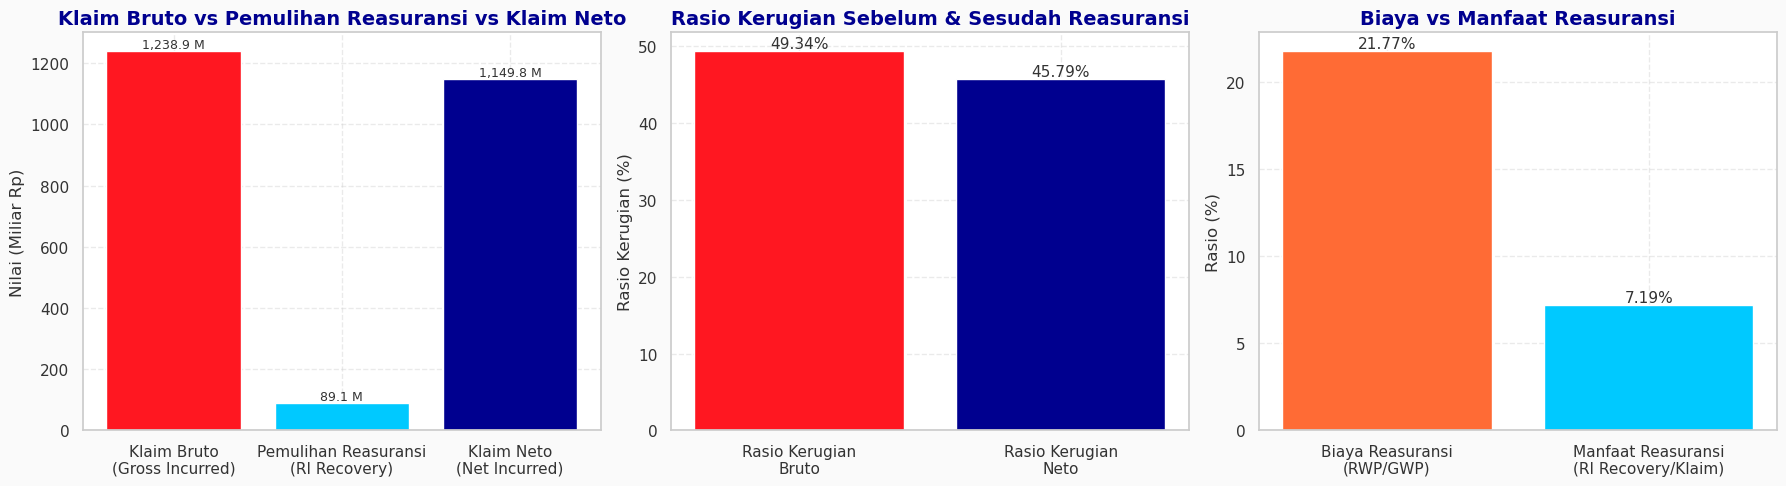

In [165]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUAL 1 — Klaim Bruto vs Pemulihan Reasuransi vs Klaim Neto
# ══════════════════════════════════════════════════════════════════════════════

values = [total['GROSS_INCURRED_CLAIM'], total['RI_RECOVERY'], total['NET_INCURRED_CLAIM']]
labels = ['Klaim Bruto\n(Gross Incurred)', 'Pemulihan Reasuransi\n(RI Recovery)', 'Klaim Neto\n(Net Incurred)']
colors_bar = [AXA_RED, AXA_TEAL, AXA_BLUE]
values_billion = [v / 1e9 for v in values]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Klaim Bruto vs RI Recovery vs Neto
ax = axes[0]
bars = ax.bar(labels, values_billion, color=colors_bar)
ax.set_title('Klaim Bruto vs Pemulihan Reasuransi vs Klaim Neto', fontweight='bold', color=AXA_BLUE)
ax.set_ylabel('Nilai (Miliar Rp)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:,.1f} M', ha='center', va='bottom', fontsize=9)

# Panel 2: Rasio Kerugian Sebelum & Sesudah Reasuransi
ax = axes[1]
ratios = [total['GROSS_LOSS_RATIO'] * 100, total['NET_LOSS_RATIO_TO_GWP'] * 100]
bars2  = ax.bar(['Rasio Kerugian\nBruto', 'Rasio Kerugian\nNeto'], ratios, color=[AXA_RED, AXA_BLUE])
ax.set_title('Rasio Kerugian Sebelum & Sesudah Reasuransi', fontweight='bold', color=AXA_BLUE)
ax.set_ylabel('Rasio Kerugian (%)')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}%', ha='center', va='bottom')

# Panel 3: Biaya vs Manfaat Reasuransi
ax = axes[2]
cost_benefit = [total['RWP_TO_GWP_RATIO'] * 100, total['RI_RECOVERY_RATIO'] * 100]
bars3 = ax.bar(['Biaya Reasuransi\n(RWP/GWP)', 'Manfaat Reasuransi\n(RI Recovery/Klaim)'],
               cost_benefit, color=[AXA_ORANGE, AXA_TEAL])
ax.set_title('Biaya vs Manfaat Reasuransi', fontweight='bold', color=AXA_BLUE)
ax.set_ylabel('Rasio (%)')
for bar in bars3:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

*Temuan Utama:* Reasuransi berhasil menurunkan rasio kerugian, namun dari sisi efisiensi margin, biaya premireasuransi yang dikeluarkan (rasio RWP/GWP) jauh lebih besar dibandingkan manfaat pemulihanyang diterima (rasio RI Recovery). Setiap Rp 1 biaya reasuransi hanya menghasilkan manfaatsekitar Rp 0,35. Hal ini mengindikasikan struktur reasuransi yang perlu dievaluasi ulang.

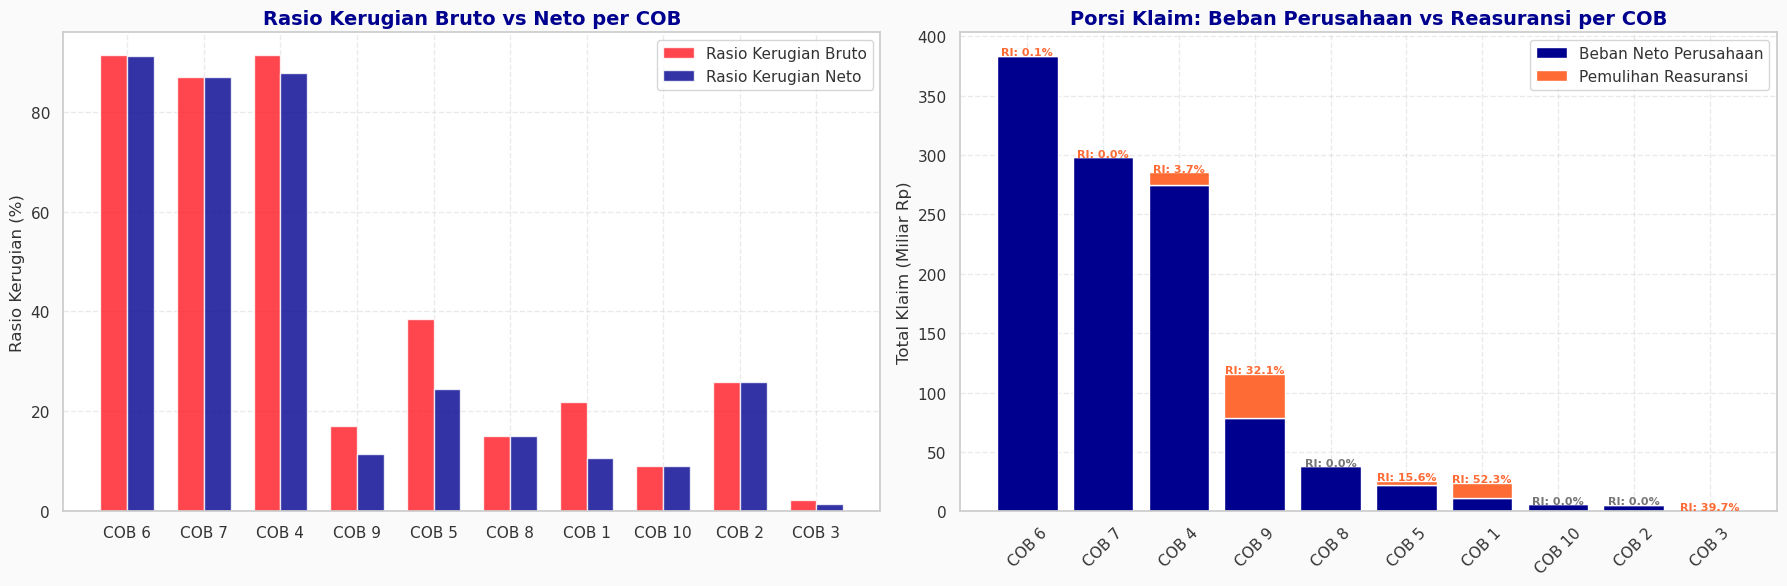

In [166]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUAL — Rasio Kerugian Bruto vs Neto per COB + Dampak Reasuransi per COB
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel Kiri: Gross vs Net Loss Ratio per COB
ax = axes[0]
plot_cob = lia_by_cob.copy()
plot_cob['GROSS_LR_PCT'] = plot_cob['GROSS_LOSS_RATIO'] * 100
plot_cob['NET_LR_PCT']   = plot_cob['NET_LOSS_RATIO_TO_GWP'] * 100
plot_cob = plot_cob.sort_values('GROSS_INCURRED_CLAIM', ascending=False).head(10)

x = np.arange(len(plot_cob))
width = 0.35
ax.bar(x - width/2, plot_cob['GROSS_LR_PCT'], width, label='Rasio Kerugian Bruto', color=AXA_RED, alpha=0.8)
ax.bar(x + width/2, plot_cob['NET_LR_PCT'], width, label='Rasio Kerugian Neto', color=AXA_BLUE, alpha=0.8)
ax.set_title('Rasio Kerugian Bruto vs Neto per COB', fontweight='bold', color=AXA_BLUE)
ax.set_ylabel('Rasio Kerugian (%)')
ax.set_xticks(x)
ax.set_xticklabels(plot_cob['COB'])
ax.legend()

# Panel Kanan: Dampak Reasuransi — Stacked Bar (Beban AXA vs RI Recovery)
ax = axes[1]
ri_analysis = settled_claims.groupby('COB').agg(
    Total_Gross_Paid=('GRS_ST_IDR', 'sum'), Total_RI_Recovery=('RI_ST_IDR', 'sum')
).reset_index()
ri_analysis['Net_Paid']     = ri_analysis['Total_Gross_Paid'] - ri_analysis['Total_RI_Recovery']
ri_analysis['RI_Pct']       = ri_analysis['Total_RI_Recovery'] / ri_analysis['Total_Gross_Paid'] * 100
ri_analysis['Gross_Billion'] = ri_analysis['Total_Gross_Paid'] / 1e9
ri_analysis['Net_Billion']   = ri_analysis['Net_Paid'] / 1e9
ri_analysis['RI_Billion']    = ri_analysis['Total_RI_Recovery'] / 1e9
ri_analysis = ri_analysis.sort_values('Total_Gross_Paid', ascending=False)

ax.bar(ri_analysis['COB'], ri_analysis['Net_Billion'], color=AXA_BLUE, label='Beban Neto Perusahaan')
ax.bar(ri_analysis['COB'], ri_analysis['RI_Billion'], bottom=ri_analysis['Net_Billion'],
       color=AXA_ORANGE, label='Pemulihan Reasuransi')
for i, (_, row) in enumerate(ri_analysis.iterrows()):
    ax.text(i, row['Gross_Billion'] + 0.5, f"RI: {row['RI_Pct']:.1f}%",
            ha='center', fontsize=8, fontweight='bold', color=AXA_ORANGE if row['RI_Pct'] > 0 else AXA_GRAY)
ax.set_title('Porsi Klaim: Beban Perusahaan vs Reasuransi per COB', fontweight='bold', color=AXA_BLUE)
ax.set_ylabel('Total Klaim (Miliar Rp)')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

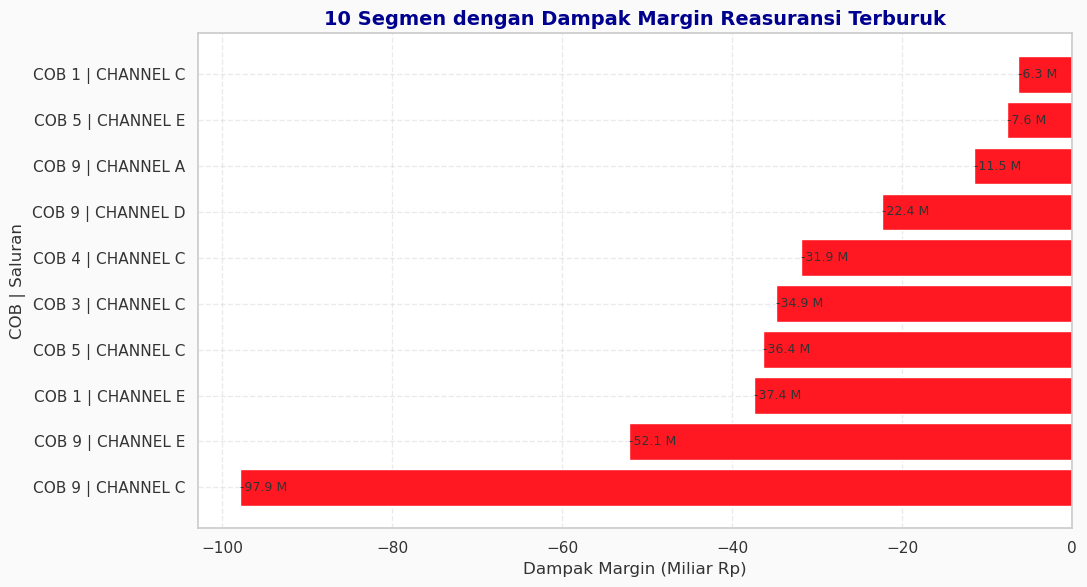


--- Segmen dengan Reasuransi Tidak Efisien ---
   COB 9 | CHANNEL C    | Dampak Margin:      Rp -97.9 M | Status: Kurang Efisien
   COB 9 | CHANNEL E    | Dampak Margin:      Rp -52.1 M | Status: Kurang Efisien
   COB 1 | CHANNEL E    | Dampak Margin:      Rp -37.4 M | Status: Kurang Efisien
   COB 5 | CHANNEL C    | Dampak Margin:      Rp -36.4 M | Status: Kurang Efisien
   COB 3 | CHANNEL C    | Dampak Margin:      Rp -34.9 M | Status: Kurang Efisien
   COB 4 | CHANNEL C    | Dampak Margin:      Rp -31.9 M | Status: Kurang Efisien
   COB 9 | CHANNEL D    | Dampak Margin:      Rp -22.4 M | Status: Kurang Efisien
   COB 9 | CHANNEL A    | Dampak Margin:      Rp -11.5 M | Status: Kurang Efisien
   COB 5 | CHANNEL E    | Dampak Margin:       Rp -7.6 M | Status: Kurang Efisien
   COB 1 | CHANNEL C    | Dampak Margin:       Rp -6.3 M | Status: Kurang Efisien


In [167]:
# ══════════════════════════════════════════════════════════════════════════════
# TOP 10 SEGMEN DENGAN DAMPAK MARGIN REASURANSI TERBURUK
# ══════════════════════════════════════════════════════════════════════════════

worst_segment = lia_by_cob_channel.copy()
worst_segment['SEGMENT'] = worst_segment['COB'].astype(str) + ' | ' + worst_segment['CHANNEL_'].astype(str)
worst_segment = worst_segment.sort_values('REINSURANCE_MARGIN_IMPACT').head(10)
worst_segment['MARGIN_IMPACT_BILLION'] = worst_segment['REINSURANCE_MARGIN_IMPACT'] / 1e9

plt.figure(figsize=(11, 6))
bars = plt.barh(worst_segment['SEGMENT'], worst_segment['MARGIN_IMPACT_BILLION'], color=AXA_RED)
plt.title('10 Segmen dengan Dampak Margin Reasuransi Terburuk', fontweight='bold', color=AXA_BLUE)
plt.xlabel('Dampak Margin (Miliar Rp)')
plt.ylabel('COB | Saluran')
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y() + bar.get_height()/2, f'{w:,.1f} M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- Tabel Segmen Tidak Efisien ---
inefficient = lia_by_cob_channel[lia_by_cob_channel['REINSURANCE_MARGIN_IMPACT'] < 0].copy()
inefficient = inefficient.sort_values('REINSURANCE_MARGIN_IMPACT')
print("\n--- Segmen dengan Reasuransi Tidak Efisien ---")
for _, r in inefficient.head(10).iterrows():
    print(f"  {r['COB']:>6} | {r['CHANNEL_']:<12} | "
          f"Dampak Margin: {fmt_rupiah(r['REINSURANCE_MARGIN_IMPACT']):>15} | "
          f"Status: {r['REINSURANCE_STATUS']}")

# 6. Deteksi Pencilan & Teori Nilai Ekstrem (IQR + EVT)
Bagian ini menggunakan dua metode statistik untuk mendeteksi klaim anomali:1. **Metode IQR** (*Interquartile Range*) — menandai klaim yang melampaui batas atas   Q3 + 1,5×IQR sebagai pencilan (*outlier*)2. **Teori Nilai Ekstrem** (*Extreme Value Theory / EVT*) — memodelkan distribusi   ekor klaim menggunakan pendekatan *Peaks Over Threshold* (POT) untuk memahami   risiko kerugian ekstrem

## 6.1 Statistik Deskriptif & Distribusi Klaim
Langkah pertama adalah memahami karakteristik distribusi klaim secara keseluruhan.Perbandingan antara *Mean* dan *Median* mengungkap tingkat kemiringan (*skewness*) distribusi— indikator utama bahwa sebagian kecil klaim besar mendominasi total kerugian.

In [168]:
# ══════════════════════════════════════════════════════════════════════════════
# STATISTIK DESKRIPTIF — Klaim yang Sudah Terbayarkan (GRS_ST_IDR > 0)
# ══════════════════════════════════════════════════════════════════════════════

df_settled = df_claim[df_claim['GRS_ST_IDR'] > 0].copy().reset_index(drop=True)
grs = df_settled['GRS_ST_IDR']

Q1  = grs.quantile(0.25)
Q3  = grs.quantile(0.75)
IQR = Q3 - Q1
UPPER_FENCE = Q3 + 1.5 * IQR

print("=" * 65)
print("  STATISTIK DESKRIPTIF — Klaim Terbayarkan (GRS_ST_IDR)")
print("=" * 65)
stats_items = [
    ('Jumlah Klaim (N)',       f"{len(grs):,}"),
    ('Total Klaim',            fmt_rupiah(grs.sum())),
    ('Rata-rata (Mean)',       fmt_rupiah(grs.mean())),
    ('Median (P50)',           fmt_rupiah(grs.median())),
    ('Std Deviasi',            fmt_rupiah(grs.std())),
    ('P25 (Q1)',               fmt_rupiah(Q1)),
    ('P75 (Q3)',               fmt_rupiah(Q3)),
    ('IQR',                    fmt_rupiah(IQR)),
    ('Batas Atas IQR (×1.5)',  fmt_rupiah(UPPER_FENCE)),
    ('P90',                    fmt_rupiah(grs.quantile(0.90))),
    ('P95',                    fmt_rupiah(grs.quantile(0.95))),
    ('P99',                    fmt_rupiah(grs.quantile(0.99))),
    ('Maksimum',               fmt_rupiah(grs.max())),
    ('Skewness',               f"{grs.skew():.2f}"),
    ('Kurtosis',               f"{grs.kurt():.2f}"),
    ('Rasio Mean/Median',      f"{grs.mean()/grs.median():.2f}×"),
    ('Koef. Variasi (CV)',     f"{grs.std()/grs.mean()*100:.1f}%"),
]
for k, v in stats_items:
    print(f"  {k:.<40} {v}")

print(f"\n📊 INTERPRETASI:")
print(f"  • Rasio Mean/Median = {grs.mean()/grs.median():.1f}× → distribusi sangat miring ke kanan")
print(f"  • CV = {grs.std()/grs.mean()*100:.0f}% → volatilitas klaim sangat tinggi")
print(f"  • Distribusi Log-Normal atau Pareto lebih cocok daripada distribusi Normal")

  STATISTIK DESKRIPTIF — Klaim Terbayarkan (GRS_ST_IDR)
  Jumlah Klaim (N)........................ 19,225
  Total Klaim............................. Rp 1.2 T
  Rata-rata (Mean)........................ Rp 61.6 Jt
  Median (P50)............................ Rp 4.7 Jt
  Std Deviasi............................. Rp 286.1 Jt
  P25 (Q1)................................ Rp 1.8 Jt
  P75 (Q3)................................ Rp 12.9 Jt
  IQR..................................... Rp 11.1 Jt
  Batas Atas IQR (×1.5)................... Rp 29.6 Jt
  P90..................................... Rp 66.0 Jt
  P95..................................... Rp 292.2 Jt
  P99..................................... Rp 1.2 M
  Maksimum................................ Rp 6.8 M
  Skewness................................ 10.29
  Kurtosis................................ 144.95
  Rasio Mean/Median....................... 13.23×
  Koef. Variasi (CV)...................... 464.8%

📊 INTERPRETASI:
  • Rasio Mean/Median = 13.2× → dist

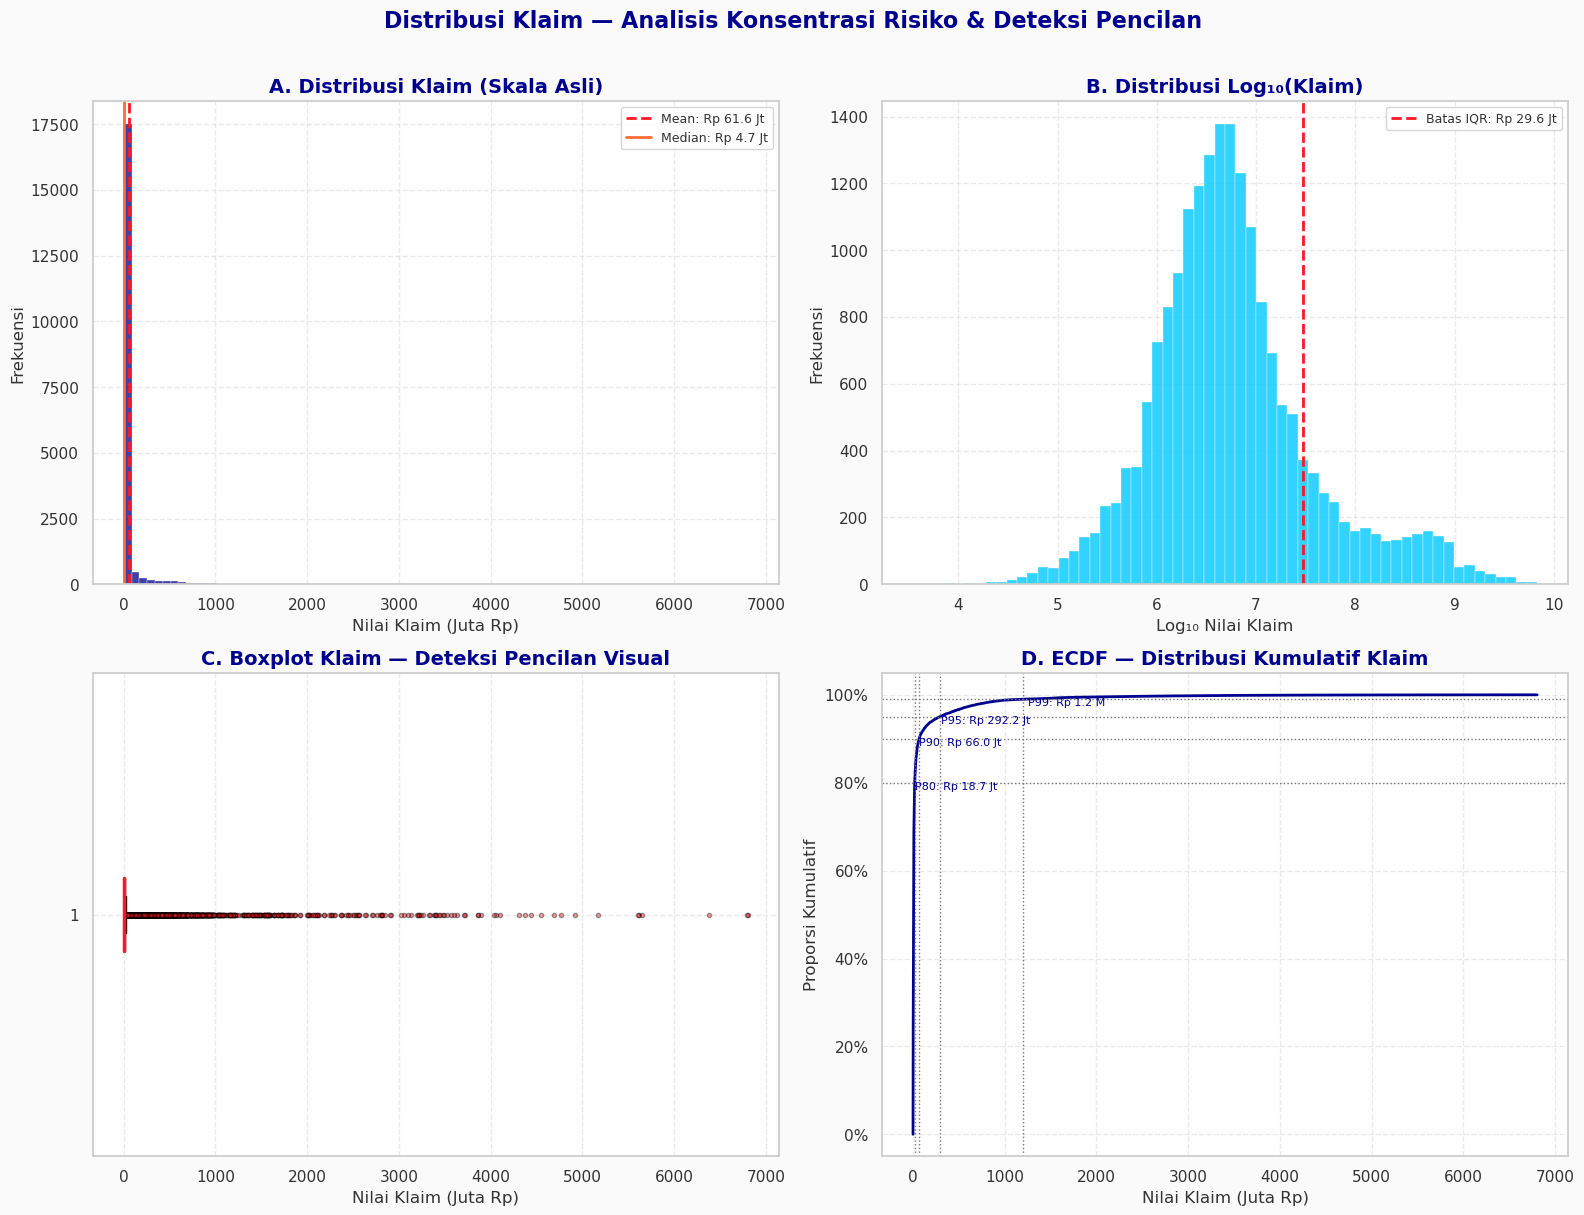

In [169]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALISASI DISTRIBUSI KLAIM — 4 Panel
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribusi Klaim — Analisis Konsentrasi Risiko & Deteksi Pencilan',
             fontsize=16, fontweight='bold', color=AXA_BLUE, y=1.01)

log_vals = np.log10(grs[grs > 0])

# Panel A: Histogram skala asli
ax = axes[0, 0]
ax.hist(grs / 1e6, bins=80, color=AXA_BLUE, alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(grs.mean() / 1e6,   color=AXA_RED,    lw=2, ls='--', label=f'Mean: {fmt_rupiah(grs.mean())}')
ax.axvline(grs.median() / 1e6, color=AXA_ORANGE, lw=2, ls='-',  label=f'Median: {fmt_rupiah(grs.median())}')
ax.set_title('A. Distribusi Klaim (Skala Asli)', color=AXA_BLUE)
ax.set_xlabel('Nilai Klaim (Juta Rp)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# Panel B: Histogram log-transformed
ax = axes[0, 1]
ax.hist(log_vals, bins=60, color=AXA_TEAL, alpha=0.80, edgecolor='white', linewidth=0.3)
ax.axvline(np.log10(UPPER_FENCE), color=AXA_RED, lw=2, ls='--', label=f'Batas IQR: {fmt_rupiah(UPPER_FENCE)}')
ax.set_title('B. Distribusi Log₁₀(Klaim)', color=AXA_BLUE)
ax.set_xlabel('Log₁₀ Nilai Klaim')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# Panel C: Boxplot
ax = axes[1, 0]
ax.boxplot(grs / 1e6, vert=False, patch_artist=True,
           boxprops=dict(facecolor=AXA_LIGHT, color=AXA_BLUE),
           medianprops=dict(color=AXA_RED, linewidth=2.5),
           flierprops=dict(marker='o', markerfacecolor=AXA_RED, markersize=3, alpha=0.4, linestyle='none'))
ax.set_title('C. Boxplot Klaim — Deteksi Pencilan Visual', color=AXA_BLUE)
ax.set_xlabel('Nilai Klaim (Juta Rp)')

# Panel D: ECDF
ax = axes[1, 1]
sorted_grs = np.sort(grs)
ecdf_y = np.arange(1, len(sorted_grs) + 1) / len(sorted_grs)
ax.plot(sorted_grs / 1e6, ecdf_y, color=AXA_BLUE, lw=2)
for pct in [0.80, 0.90, 0.95, 0.99]:
    val = np.quantile(grs, pct)
    ax.axhline(pct, color=AXA_GRAY, lw=1, ls=':')
    ax.axvline(val / 1e6, color=AXA_GRAY, lw=1, ls=':')
    ax.text(val / 1e6 * 1.05, pct - 0.015, f'P{int(pct*100)}: {fmt_rupiah(val)}', fontsize=8, color=AXA_BLUE)
ax.set_title('D. ECDF — Distribusi Kumulatif Klaim', color=AXA_BLUE)
ax.set_xlabel('Nilai Klaim (Juta Rp)')
ax.set_ylabel('Proporsi Kumulatif')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

## 6.2 Deteksi Pencilan IQR & Analisis Pareto

In [170]:
# ══════════════════════════════════════════════════════════════════════════════
# DETEKSI PENCILAN IQR — Kuantifikasi Klaim Ekstrem
# ══════════════════════════════════════════════════════════════════════════════

df_outlier = df_settled[df_settled['GRS_ST_IDR'] > UPPER_FENCE].copy()
df_normal  = df_settled[df_settled['GRS_ST_IDR'] <= UPPER_FENCE].copy()

n_total       = len(df_settled)
n_outlier     = len(df_outlier)
pct_outlier_n = n_outlier / n_total * 100
total_klaim_val = grs.sum()
total_outlier   = df_outlier['GRS_ST_IDR'].sum()
pct_outlier_v   = total_outlier / total_klaim_val * 100

print("=" * 65)
print("  HASIL DETEKSI PENCILAN — METODE IQR (×1.5)")
print("=" * 65)
print(f"  Batas Atas IQR      : {fmt_rupiah(UPPER_FENCE)}")
print(f"  Jumlah pencilan     : {n_outlier:,} ({pct_outlier_n:.1f}% dari total)")
print(f"  Nilai pencilan      : {fmt_rupiah(total_outlier)} ({pct_outlier_v:.1f}% dari total)")
print(f"  Mean klaim pencilan : {fmt_rupiah(df_outlier['GRS_ST_IDR'].mean())}")
print(f"  Mean klaim normal   : {fmt_rupiah(df_normal['GRS_ST_IDR'].mean())}")
print(f"  Rasio Mean          : {df_outlier['GRS_ST_IDR'].mean()/df_normal['GRS_ST_IDR'].mean():.1f}× lebih besar")
print(f"\n  ⚠️ TEMUAN: Hanya {pct_outlier_n:.1f}% klaim menyumbang {pct_outlier_v:.1f}% total kerugian")

# ── Analisis Pareto ──────────────────────────────────────────────────────────
df_sorted = df_settled.sort_values('GRS_ST_IDR', ascending=False).reset_index(drop=True)
df_sorted['cum_value'] = df_sorted['GRS_ST_IDR'].cumsum()
df_sorted['cum_pct_value'] = df_sorted['cum_value'] / total_klaim_val * 100
df_sorted['cum_pct_count'] = (df_sorted.index + 1) / n_total * 100

idx_80 = (df_sorted['cum_pct_value'] >= 80).idxmax()
pct_klaim_80 = df_sorted.loc[idx_80, 'cum_pct_count']

print(f"\n  Analisis Pareto:")
print(f"  80% total kerugian berasal dari top {pct_klaim_80:.1f}% klaim terbesar")
for pct_label, pct_val in [(1, 0.01), (5, 0.05), (10, 0.10)]:
    idx = max(0, int(n_total * pct_val) - 1)
    print(f"  Top {pct_label}% klaim menyumbang {df_sorted.loc[:idx, 'cum_pct_value'].max():.1f}% total kerugian")

  HASIL DETEKSI PENCILAN — METODE IQR (×1.5)
  Batas Atas IQR      : Rp 29.6 Jt
  Jumlah pencilan     : 2,920 (15.2% dari total)
  Nilai pencilan      : Rp 1.1 T (92.2% dari total)
  Mean klaim pencilan : Rp 373.6 Jt
  Mean klaim normal   : Rp 5.7 Jt
  Rasio Mean          : 65.8× lebih besar

  ⚠️ TEMUAN: Hanya 15.2% klaim menyumbang 92.2% total kerugian

  Analisis Pareto:
  80% total kerugian berasal dari top 5.8% klaim terbesar
  Top 1% klaim menyumbang 38.2% total kerugian
  Top 5% klaim menyumbang 76.7% total kerugian
  Top 10% klaim menyumbang 88.5% total kerugian


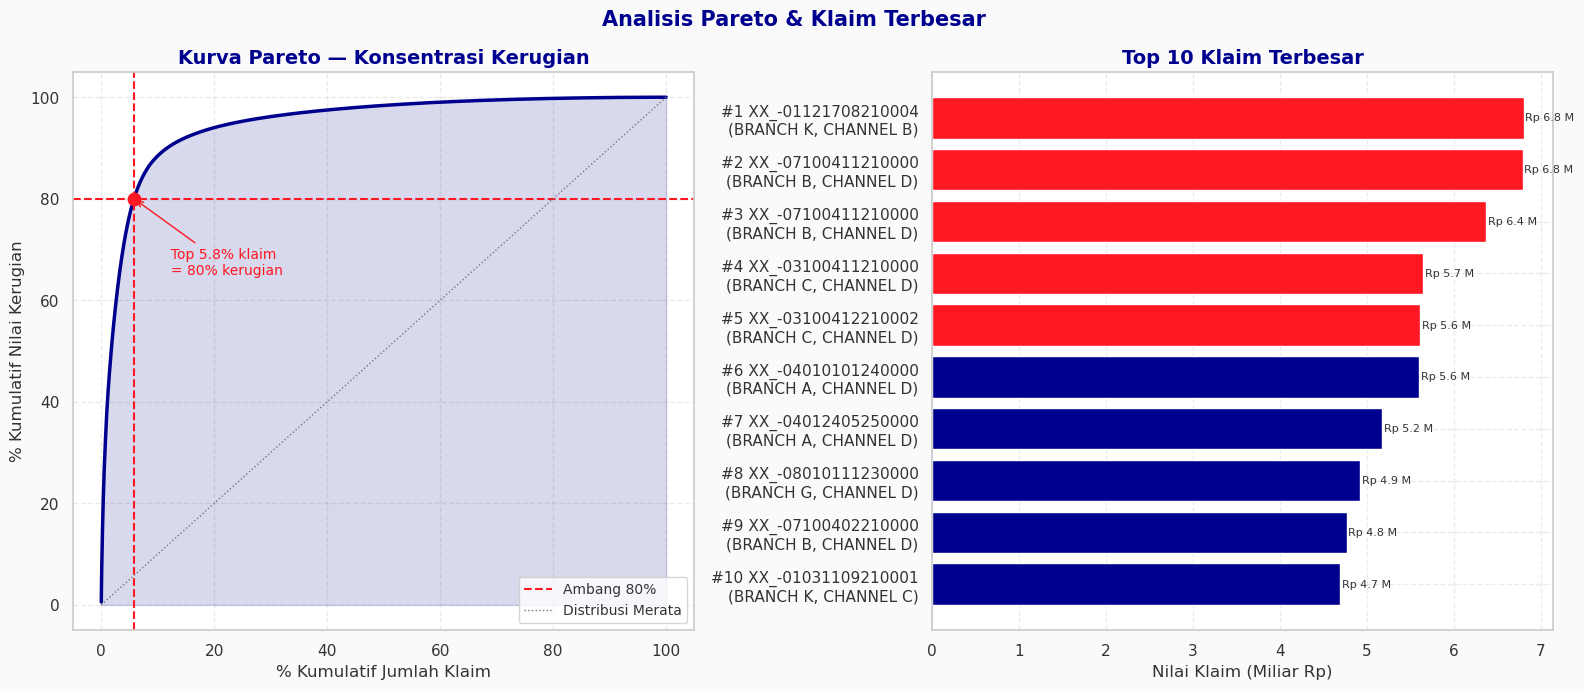

In [171]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALISASI PARETO & TOP 10 KLAIM TERBESAR
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Pareto & Klaim Terbesar', fontsize=15, fontweight='bold', color=AXA_BLUE)

# Panel Kiri: Kurva Pareto
ax = axes[0]
ax.plot(df_sorted['cum_pct_count'], df_sorted['cum_pct_value'], color=AXA_BLUE, lw=2.5)
ax.fill_between(df_sorted['cum_pct_count'], df_sorted['cum_pct_value'], alpha=0.15, color=AXA_BLUE)
ax.axhline(80, color=AXA_RED, lw=1.5, ls='--', label='Ambang 80%')
ax.axvline(pct_klaim_80, color=AXA_RED, lw=1.5, ls='--')
ax.scatter([pct_klaim_80], [80], color=AXA_RED, s=80, zorder=5)
ax.annotate(f'  Top {pct_klaim_80:.1f}% klaim\n  = 80% kerugian',
            xy=(pct_klaim_80, 80), xytext=(pct_klaim_80 + 5, 65),
            fontsize=10, color=AXA_RED, arrowprops=dict(arrowstyle='->', color=AXA_RED))
ax.plot([0, 100], [0, 100], color=AXA_GRAY, lw=1, ls=':', label='Distribusi Merata')
ax.set_xlabel('% Kumulatif Jumlah Klaim')
ax.set_ylabel('% Kumulatif Nilai Kerugian')
ax.set_title('Kurva Pareto — Konsentrasi Kerugian', color=AXA_BLUE)
ax.legend(fontsize=10)

# Panel Kanan: Top 10 Klaim
ax = axes[1]
top10 = df_sorted.head(10).copy()
top10_labels = [f"#{i+1} {r['CLM_REF'][:18]}\n({r['BRANCH_']}, {r['CHANNEL_']})"
                for i, (_, r) in enumerate(top10.iterrows())]
bars = ax.barh(top10_labels, top10['GRS_ST_IDR'] / 1e9,
               color=[AXA_RED if i < 5 else AXA_BLUE for i in range(10)],
               edgecolor='white')
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2, f'{fmt_rupiah(w*1e9)}', va='center', fontsize=8)
ax.set_xlabel('Nilai Klaim (Miliar Rp)')
ax.set_title('Top 10 Klaim Terbesar', color=AXA_BLUE)

plt.tight_layout()
plt.show()

## 6.3 Konsentrasi Pencilan per Saluran Distribusi & Cabang

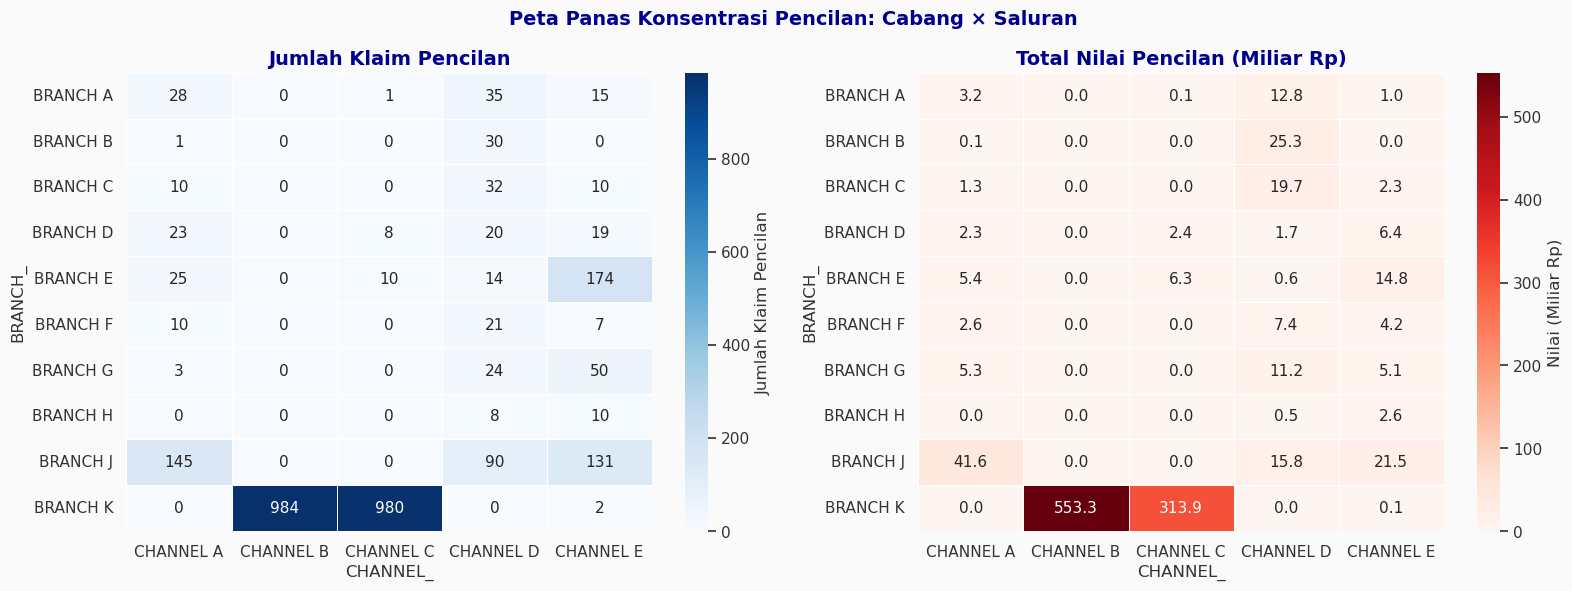

In [172]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALISIS PENCILAN PER SALURAN & CABANG + HEATMAP
# ══════════════════════════════════════════════════════════════════════════════

# --- Per Channel ---
ch_stats = df_settled.groupby('CHANNEL_').agg(
    total_klaim=('GRS_ST_IDR', 'sum'), jumlah_klaim=('GRS_ST_IDR', 'count')
).reset_index()
ch_outlier = df_outlier.groupby('CHANNEL_').agg(
    n_outlier=('GRS_ST_IDR', 'count'), total_outlier=('GRS_ST_IDR', 'sum')
).reset_index()
ch_stats = ch_stats.merge(ch_outlier, on='CHANNEL_', how='left').fillna(0)
ch_stats['pct_outlier_v'] = ch_stats['total_outlier'] / ch_stats['total_klaim'] * 100
ch_stats = ch_stats.sort_values('total_klaim', ascending=False)

# --- Per Branch ---
br_stats = df_settled.groupby('BRANCH_').agg(
    total_klaim=('GRS_ST_IDR', 'sum'), jumlah_klaim=('GRS_ST_IDR', 'count')
).reset_index()
br_outlier = df_outlier.groupby('BRANCH_').agg(
    n_outlier=('GRS_ST_IDR', 'count'), total_outlier=('GRS_ST_IDR', 'sum')
).reset_index()
br_stats = br_stats.merge(br_outlier, on='BRANCH_', how='left').fillna(0)
br_stats['pct_outlier_v'] = br_stats['total_outlier'] / br_stats['total_klaim'] * 100
br_stats = br_stats.sort_values('total_klaim', ascending=False)

# --- Heatmap Branch × Channel ---
pivot_cnt = df_outlier.groupby(['BRANCH_', 'CHANNEL_'])['GRS_ST_IDR'].count().unstack(fill_value=0)
pivot_val = df_outlier.groupby(['BRANCH_', 'CHANNEL_'])['GRS_ST_IDR'].sum().unstack(fill_value=0) / 1e9

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Peta Panas Konsentrasi Pencilan: Cabang × Saluran', fontsize=14, fontweight='bold', color=AXA_BLUE)

sns.heatmap(pivot_cnt, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Jumlah Klaim Pencilan'})
axes[0].set_title('Jumlah Klaim Pencilan', color=AXA_BLUE)

sns.heatmap(pivot_val, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Nilai (Miliar Rp)'})
axes[1].set_title('Total Nilai Pencilan (Miliar Rp)', color=AXA_BLUE)

plt.tight_layout()
plt.show()

## 6.4 Teori Nilai Ekstrem (EVT) — Analisis Risiko Ekor

  TEORI NILAI EKSTREM (EVT) — ANALISIS RISIKO EKOR
  Ambang batas (Upper IQR Fence) : Rp 29.6 Jt
  Jumlah klaim di atas ambang    : 2,920
  Parameter Log-Normal (MLE):
    μ (skala log) = 18.8745
    σ (skala log) = 1.2569


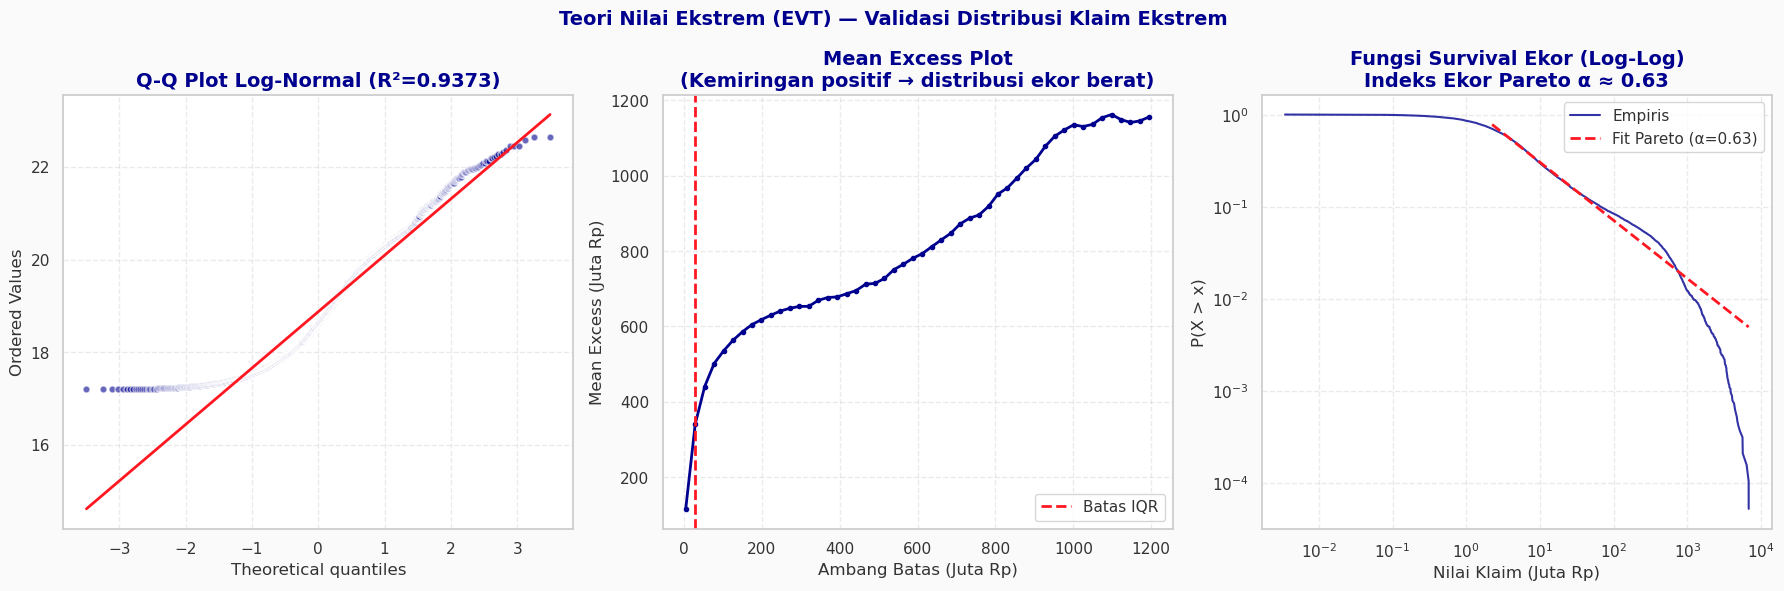


📊 INTERPRETASI EVT:
  • Q-Q Plot mengkonfirmasi distribusi mendekati Log-Normal
  • Mean Excess Plot dengan kemiringan positif → distribusi ekor berat
  • Indeks Ekor Pareto (α ≈ 0.63): semakin kecil α, semakin berat ekor distribusi


In [173]:
# ══════════════════════════════════════════════════════════════════════════════
# EXTREME VALUE THEORY (EVT) — Validasi Distribusi & Tail Risk
# ══════════════════════════════════════════════════════════════════════════════

# Fit distribusi Log-Normal terhadap klaim pencilan
ln_mu, ln_sigma = stats.norm.fit(np.log(df_outlier['GRS_ST_IDR']))

print("=" * 65)
print("  TEORI NILAI EKSTREM (EVT) — ANALISIS RISIKO EKOR")
print("=" * 65)
print(f"  Ambang batas (Upper IQR Fence) : {fmt_rupiah(UPPER_FENCE)}")
print(f"  Jumlah klaim di atas ambang    : {n_outlier:,}")
print(f"  Parameter Log-Normal (MLE):")
print(f"    μ (skala log) = {ln_mu:.4f}")
print(f"    σ (skala log) = {ln_sigma:.4f}")

# --- Visualisasi EVT ---
grs_sorted = np.sort(grs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Teori Nilai Ekstrem (EVT) — Validasi Distribusi Klaim Ekstrem',
             fontsize=14, fontweight='bold', color=AXA_BLUE)

# Q-Q Plot Log-Normal
ax = axes[0]
log_data = np.log(df_outlier['GRS_ST_IDR'])
(osm, osr), (slope, intercept, r) = stats.probplot(log_data, dist='norm', plot=ax)
ax.get_lines()[0].set(marker='o', markerfacecolor=AXA_BLUE, markeredgecolor='white', markersize=5, alpha=0.6)
ax.get_lines()[1].set(color=AXA_RED, linewidth=2)
ax.set_title(f'Q-Q Plot Log-Normal (R²={r**2:.4f})', color=AXA_BLUE)

# Mean Excess Plot
ax = axes[1]
thresholds = np.linspace(grs.quantile(0.5), grs.quantile(0.99), 50)
mean_excess_vals = [grs[grs > t].mean() - t for t in thresholds if (grs > t).sum() > 5]
thresholds_valid = thresholds[:len(mean_excess_vals)]
ax.plot(thresholds_valid / 1e6, np.array(mean_excess_vals) / 1e6, color=AXA_BLUE, lw=2, marker='o', markersize=3)
ax.axvline(UPPER_FENCE / 1e6, color=AXA_RED, lw=2, ls='--', label=f'Batas IQR')
ax.set_title('Mean Excess Plot\n(Kemiringan positif → distribusi ekor berat)', color=AXA_BLUE)
ax.set_xlabel('Ambang Batas (Juta Rp)')
ax.set_ylabel('Mean Excess (Juta Rp)')
ax.legend()

# Tail Distribution (Log-Log)
ax = axes[2]
sf_vals = 1 - np.arange(1, len(grs_sorted)+1) / (len(grs_sorted)+1)
ax.loglog(grs_sorted / 1e6, sf_vals, color=AXA_BLUE, lw=1.5, alpha=0.8, label='Empiris')
# Fit Pareto tail
idx_fit = int(len(grs_sorted) * 0.3)
x_fit, sf_fit = grs_sorted[idx_fit:], sf_vals[idx_fit:]
slope_tail, inter_tail = np.polyfit(np.log(x_fit), np.log(sf_fit + 1e-10), 1)
x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
ax.loglog(x_line / 1e6, np.exp(inter_tail + slope_tail * np.log(x_line)),
          color=AXA_RED, lw=2, ls='--', label=f'Fit Pareto (α={-slope_tail:.2f})')
ax.set_title(f'Fungsi Survival Ekor (Log-Log)\nIndeks Ekor Pareto α ≈ {-slope_tail:.2f}', color=AXA_BLUE)
ax.set_xlabel('Nilai Klaim (Juta Rp)')
ax.set_ylabel('P(X > x)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 INTERPRETASI EVT:")
print(f"  • Q-Q Plot mengkonfirmasi distribusi mendekati Log-Normal")
print(f"  • Mean Excess Plot dengan kemiringan positif → distribusi ekor berat")
print(f"  • Indeks Ekor Pareto (α ≈ {-slope_tail:.2f}): semakin kecil α, semakin berat ekor distribusi")

# 7. Pencadangan Deterministik, Rasio Klaim Tertunggak & Analisis Durasi
Bagian terakhir ini menganalisis:1. **Distribusi durasi klaim** (*Time-to-Claim / Vintage Analysis*) — berapa lama   setelah polis aktif nasabah mengajukan klaim2. **Pelacakan klaim dini** (*Day-0 Claims*) — klaim yang diajukan di hari pertama polis3. **Kecukupan pencadangan** (*Reserving Adequacy*) — rasio klaim tertunggak terhadap terbayar4. **Tren klaim tahunan** — perkembangan frekuensi dan keparahan klaim dari waktu ke waktu

## 7.1 Analisis Vintage — Distribusi Durasi KlaimAnalisis ini berfokus pada CHANNEL B yang menunjukkan indikasi anomali klaim,untuk mengidentifikasi pola *anti-seleksi* atau potensi kecurangan (*fraud*).

Analisis Vintage — Distribusi Durasi Klaim (Channel B)
─────────────────────────────────────────────────────────────────
  1. Super Cepat (≤ 30 Hari)..............    725 klaim        Rp 15.1 M
  2. Cepat (31 – 90 Hari).................    588 klaim        Rp 47.5 M
  3. Normal (> 90 Hari)...................   1296 klaim       Rp 499.5 M


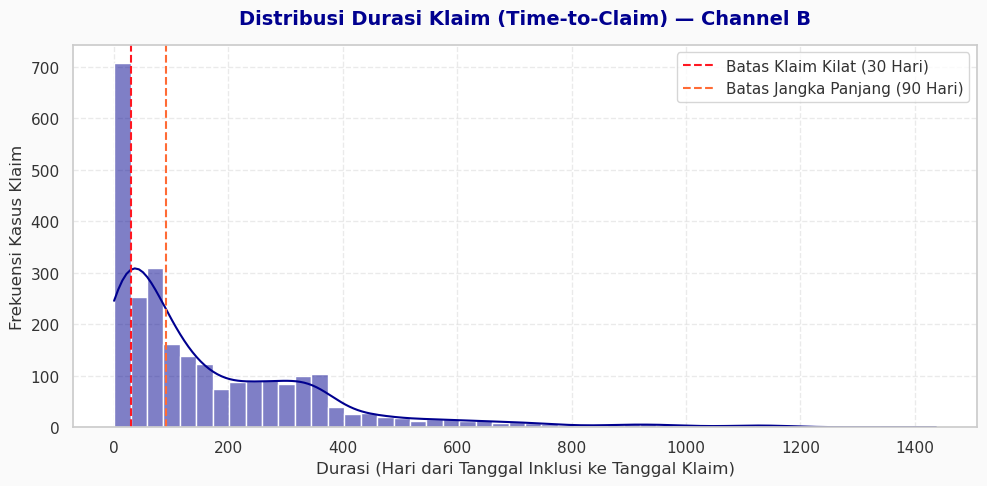

In [174]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALISIS VINTAGE — Durasi Klaim (Time-to-Claim)
# ══════════════════════════════════════════════════════════════════════════════

# Merge tanggal inklusi polis ke data klaim
df_prem_sub = df_premium[['POLICY_NO', 'DT_INC']].drop_duplicates(subset=['POLICY_NO'])
df_merged = pd.merge(df_claim, df_prem_sub, on='POLICY_NO', how='inner')
df_merged['Time_to_Claim'] = (df_merged['DT_CLM'] - df_merged['DT_INC']).dt.days

# Fokus pada Channel B
df_b = df_merged[df_merged['CHANNEL_'] == 'CHANNEL B'].copy()
df_b['Kategori_Vintage'] = df_b['Time_to_Claim'].apply(kelompok_waktu)

# --- Ringkasan Vintage ---
vintage_summary = df_b.groupby('Kategori_Vintage').agg(
    Jumlah_Kejadian_Klaim=('CLM_REF', 'count'),
    Total_Biaya_Klaim=('GRS_ST_IDR', 'sum')
).reset_index()

print("Analisis Vintage — Distribusi Durasi Klaim (Channel B)")
print("─" * 65)
for _, row in vintage_summary.iterrows():
    print(f"  {row['Kategori_Vintage']:.<40} {row['Jumlah_Kejadian_Klaim']:>6} klaim  "
          f"{fmt_rupiah(row['Total_Biaya_Klaim']):>15}")

# --- Visualisasi Histogram ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df_b, x='Time_to_Claim', bins=50, kde=True, color=AXA_BLUE, edgecolor='white')
plt.axvline(x=30, color=AXA_RED, linestyle='--', linewidth=1.5, label='Batas Klaim Kilat (30 Hari)')
plt.axvline(x=90, color=AXA_ORANGE, linestyle='--', linewidth=1.5, label='Batas Jangka Panjang (90 Hari)')
plt.title('Distribusi Durasi Klaim (Time-to-Claim) — Channel B', pad=15, fontweight='bold', color=AXA_BLUE)
plt.xlabel('Durasi (Hari dari Tanggal Inklusi ke Tanggal Klaim)')
plt.ylabel('Frekuensi Kasus Klaim')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Temuan Vintage Channel B:**- Terdapat **725 klaim prematur** (≤ 30 hari) yang mengindikasikan celah anti-seleksi- Klaim jangka panjang (> 90 hari) menyedot kas hingga ratusan miliar Rupiah- **Seluruh klaim terkonsentrasi di satu cabang saja (BRANCH K)**, menunjukkan  bahwa ini bukan kelemahan sistemik nasional, melainkan isu lokal yang spesifik


Sebaran Vintage per Cabang (Channel B):
───────────────────────────────────────────────────────────────────────────
  1. Super Cepat (≤ 30 Hari).... BRANCH K       725 klaim        Rp 15.1 M  Rata-rata: 13.7 hari
  2. Cepat (31 – 90 Hari)....... BRANCH K       588 klaim        Rp 47.5 M  Rata-rata: 62.5 hari
  3. Normal (> 90 Hari)......... BRANCH K      1296 klaim       Rp 499.5 M  Rata-rata: 308.2 hari

Klaim Hari ke-0 per Lini Bisnis (75 total kasus):
───────────────────────────────────────────────────────────────────────────
  COB 6.......   65 kasus  Total:      Rp 91.3 Jt  Rata-rata:    Rp 1.4 Jt/kasus
  COB 10......    9 kasus  Total:      Rp 78.0 Jt  Rata-rata:    Rp 8.7 Jt/kasus
  COB 2.......    1 kasus  Total:      Rp 16.2 Jt  Rata-rata:   Rp 16.2 Jt/kasus


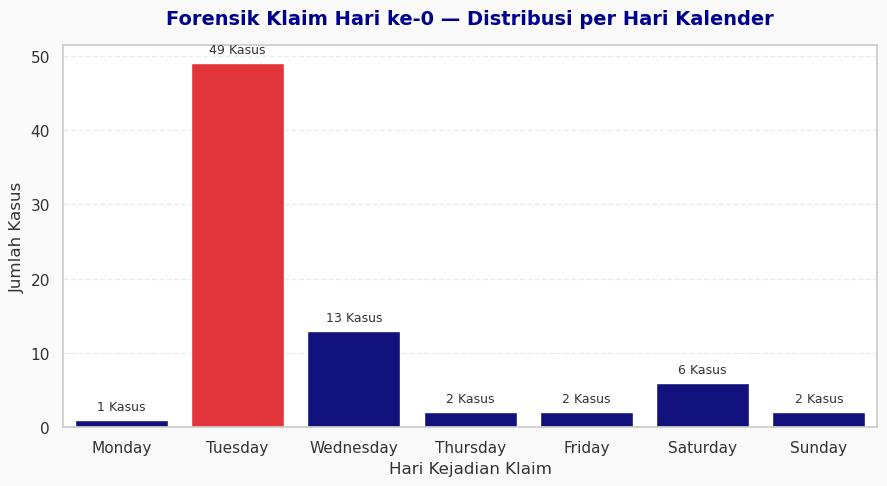

In [175]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALISIS KLAIM HARI KE-0 — Pelacakan Klaim Dini
# ══════════════════════════════════════════════════════════════════════════════

# Sebaran Vintage per Branch
vintage_branch = df_b.groupby(['Kategori_Vintage', 'BRANCH_']).agg(
    Frekuensi_Klaim=('CLM_REF', 'count'),
    Total_Pembayaran=('GRS_ST_IDR', 'sum'),
    Rata_Rata_Hari=('Time_to_Claim', 'mean')
).reset_index()

print("\nSebaran Vintage per Cabang (Channel B):")
print("─" * 75)
for _, r in vintage_branch.iterrows():
    print(f"  {r['Kategori_Vintage']:.<30} {r['BRANCH_']:<12} "
          f"{r['Frekuensi_Klaim']:>5} klaim  {fmt_rupiah(r['Total_Pembayaran']):>15}  "
          f"Rata-rata: {r['Rata_Rata_Hari']:.1f} hari")

# --- Klaim Hari ke-0 per COB ---
df_day_zero = df_b[df_b['Time_to_Claim'] == 0].copy()
cob_day_zero = df_day_zero.groupby('COB').agg(
    Jumlah_Kasus=('CLM_REF', 'count'),
    Total_Bayar=('GRS_ST_IDR', 'sum'),
    Rata_Rata_Bayar=('GRS_ST_IDR', 'mean')
).reset_index().sort_values('Jumlah_Kasus', ascending=False)

print(f"\nKlaim Hari ke-0 per Lini Bisnis ({len(df_day_zero)} total kasus):")
print("─" * 75)
for _, r in cob_day_zero.iterrows():
    print(f"  {r['COB']:.<12} {r['Jumlah_Kasus']:>4} kasus  "
          f"Total: {fmt_rupiah(r['Total_Bayar']):>15}  "
          f"Rata-rata: {fmt_rupiah(r['Rata_Rata_Bayar']):>12}/kasus")

# --- Klaim Hari ke-0 per Hari Kalender ---
df_day_zero['Hari_Kejadian'] = df_day_zero['DT_CLM'].dt.day_name()
urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_analysis = df_day_zero.groupby('Hari_Kejadian').agg(
    Jumlah_Kasus=('CLM_REF', 'count'), Total_Bayar=('GRS_ST_IDR', 'sum')
).reindex(urutan_hari).fillna(0)

plt.figure(figsize=(9, 5))
palet = [AXA_RED if x == 'Tuesday' else AXA_BLUE for x in urutan_hari]
ax = sns.barplot(x=day_analysis.index, y=day_analysis['Jumlah_Kasus'], palette=palet)
plt.title('Forensik Klaim Hari ke-0 — Distribusi per Hari Kalender',
          pad=15, fontweight='bold', color=AXA_BLUE)
plt.xlabel('Hari Kejadian Klaim')
plt.ylabel('Jumlah Kasus')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())} Kasus',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, textcoords='offset points', xytext=(0, 5))
plt.tight_layout()
plt.show()

## 7.2 Kecukupan Pencadangan & Rasio Klaim Tertunggak

  KECUKUPAN PENCADANGAN — Channel B
  Klaim Terbayarkan (Paid)    : Rp 561.997.208.178.34
  Cadangan Tertunggak (OS)    : Rp 0.00
  Total Beban (Incurred)      : Rp 561.997.208.178.34
  Rasio Outstanding-to-Paid   : 0.00%

Kecukupan Pencadangan per COB (Channel B):
───────────────────────────────────────────────────────────────────────────
  COB 6.....  1415 kasus  Paid:      Rp 373.4 M  OS:         Rp 0  Rasio OS:   0.00%
  COB 7.....  1000 kasus  Paid:      Rp 178.3 M  OS:         Rp 0  Rasio OS:   0.00%
  COB 2.....    28 kasus  Paid:        Rp 5.4 M  OS:         Rp 0  Rasio OS:   0.00%
  COB 10....   160 kasus  Paid:        Rp 3.3 M  OS:         Rp 0  Rasio OS:   0.00%
  COB 9.....     4 kasus  Paid:        Rp 1.1 M  OS:         Rp 0  Rasio OS:   0.00%
  COB 4.....     1 kasus  Paid:     Rp 537.5 Jt  OS:         Rp 0  Rasio OS:   0.00%
  COB 8.....     1 kasus  Paid:       Rp 1.5 Jt  OS:         Rp 0  Rasio OS:   0.00%


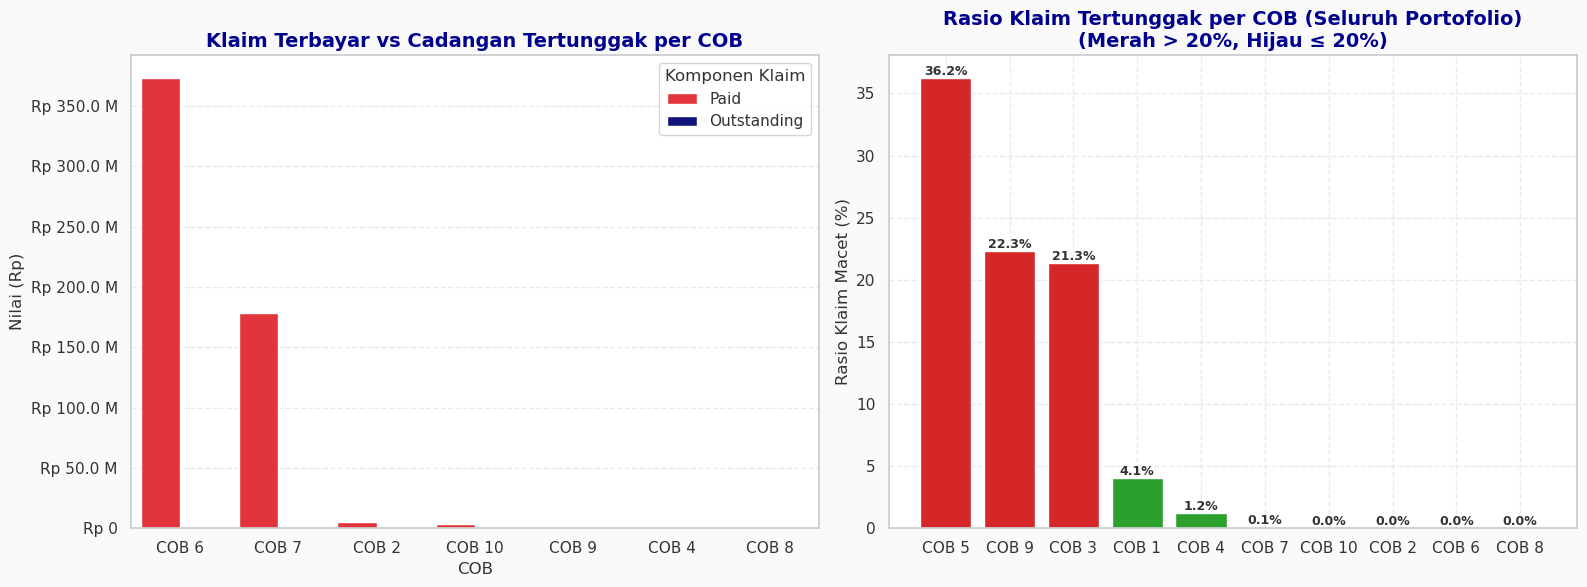

In [176]:
# ══════════════════════════════════════════════════════════════════════════════
# KECUKUPAN PENCADANGAN — Rasio Outstanding-to-Paid Claims
# ══════════════════════════════════════════════════════════════════════════════

# Analisis makro Channel B
total_paid_b = df_b['GRS_ST_IDR'].sum()
total_os_b   = df_b['GRS_OS_IDR'].sum()
total_inc_b  = total_paid_b + total_os_b
os_ratio_b   = (total_os_b / total_paid_b * 100) if total_paid_b > 0 else 0

print("=" * 65)
print("  KECUKUPAN PENCADANGAN — Channel B")
print("=" * 65)
print(f"  Klaim Terbayarkan (Paid)    : {fmt_rupiah_full(total_paid_b)}")
print(f"  Cadangan Tertunggak (OS)    : {fmt_rupiah_full(total_os_b)}")
print(f"  Total Beban (Incurred)      : {fmt_rupiah_full(total_inc_b)}")
print(f"  Rasio Outstanding-to-Paid   : {os_ratio_b:.2f}%")

# --- Per COB ---
reserving = df_b.groupby('COB').agg(
    Total_Kasus=('CLM_REF', 'count'),
    Paid=('GRS_ST_IDR', 'sum'),
    Outstanding=('GRS_OS_IDR', 'sum')
).reset_index()
reserving['Incurred'] = reserving['Paid'] + reserving['Outstanding']
reserving['Rasio_OS_Pct'] = (reserving['Outstanding'] / reserving['Incurred'] * 100).round(2)
reserving = reserving.sort_values('Incurred', ascending=False)

print("\nKecukupan Pencadangan per COB (Channel B):")
print("─" * 75)
for _, r in reserving.iterrows():
    print(f"  {r['COB']:.<10} {r['Total_Kasus']:>5} kasus  "
          f"Paid: {fmt_rupiah(r['Paid']):>15}  OS: {fmt_rupiah(r['Outstanding']):>12}  "
          f"Rasio OS: {r['Rasio_OS_Pct']:>6.2f}%")

# --- Visualisasi Paid vs Outstanding ---
df_melted = pd.melt(reserving, id_vars=['COB'], value_vars=['Paid', 'Outstanding'],
                    var_name='Tipe', value_name='Nilai')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.barplot(data=df_melted, x='COB', y='Nilai', hue='Tipe', palette=[AXA_RED, AXA_BLUE], ax=ax)
ax.set_title('Klaim Terbayar vs Cadangan Tertunggak per COB', fontweight='bold', color=AXA_BLUE)
ax.set_ylabel('Nilai (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax.legend(title='Komponen Klaim')

# Rasio klaim macet per COB (seluruh data)
ax = axes[1]
op_analysis = df_claim.groupby('COB').agg(
    Total_Kasus=('CLM_REF', 'count'),
    Kasus_Macet=('GRS_OS_IDR', lambda x: (x > 0).sum())
).reset_index()
op_analysis['Rasio_Macet_Pct'] = op_analysis['Kasus_Macet'] / op_analysis['Total_Kasus'] * 100
op_analysis = op_analysis.sort_values('Rasio_Macet_Pct', ascending=False)

colors_macet = ['#d62728' if x > 20 else '#2ca02c' for x in op_analysis['Rasio_Macet_Pct']]
bars = ax.bar(op_analysis['COB'], op_analysis['Rasio_Macet_Pct'], color=colors_macet)
for p in bars:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Rasio Klaim Tertunggak per COB (Seluruh Portofolio)\n(Merah > 20%, Hijau ≤ 20%)',
             fontweight='bold', color=AXA_BLUE)
ax.set_ylabel('Rasio Klaim Macet (%)')

plt.tight_layout()
plt.show()

## 7.3 Tren Klaim Tahunan

--- Tren Klaim Tahunan ---
  2021  |   3,556 kasus  |  Rp 574.1 M
  2022  |   6,334 kasus  |  Rp 316.1 M
  2023  |   6,068 kasus  |  Rp 201.5 M
  2024  |   3,139 kasus  |  Rp 84.4 M
  2025  |     118 kasus  |  Rp 7.2 M
  2026  |      10 kasus  |  Rp 76.8 Jt


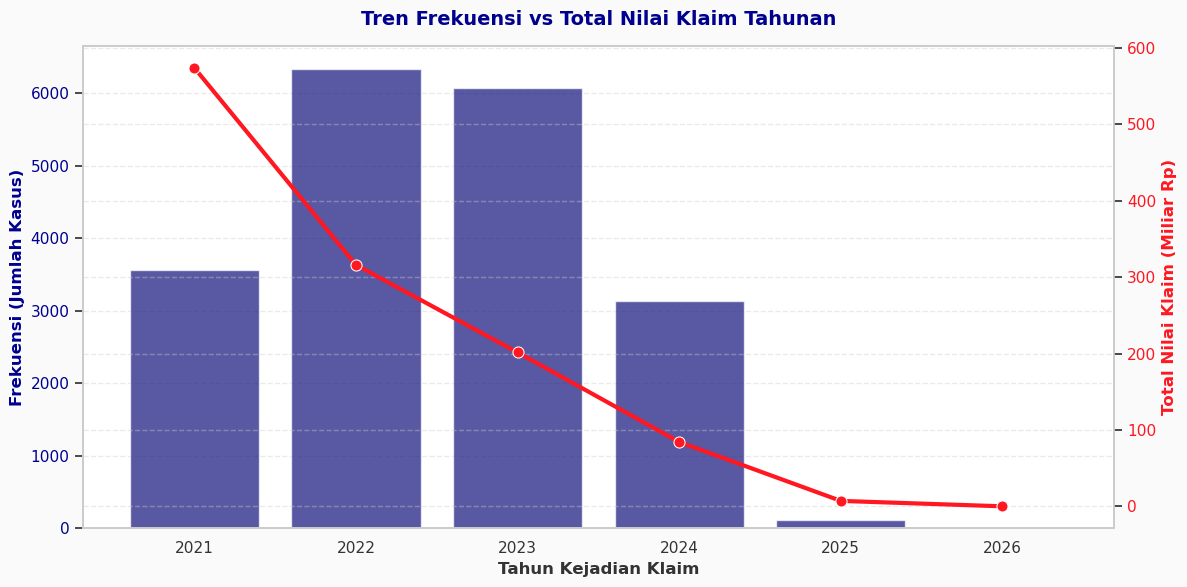

In [177]:
# ══════════════════════════════════════════════════════════════════════════════
# TREN KLAIM TAHUNAN — Frekuensi vs Keparahan
# ══════════════════════════════════════════════════════════════════════════════

settled_yearly = settled_claims.copy()
settled_yearly['Tahun_Klaim'] = pd.to_datetime(settled_yearly['DT_CLM']).dt.year

yearly = settled_yearly.groupby('Tahun_Klaim').agg(
    Jumlah_Kasus=('CLM_REF', 'count'),
    Total_Klaim_Miliar=('GRS_ST_IDR', lambda x: x.sum() / 1e9)
).reset_index()

print("--- Tren Klaim Tahunan ---")
for _, r in yearly.iterrows():
    print(f"  {int(r['Tahun_Klaim'])}  |  {int(r['Jumlah_Kasus']):>6,} kasus  |  {fmt_rupiah(r['Total_Klaim_Miliar'] * 1e9)}")

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=yearly, x='Tahun_Klaim', y='Jumlah_Kasus', ax=ax1, color=AXA_BLUE, alpha=0.7)
ax1.set_title('Tren Frekuensi vs Total Nilai Klaim Tahunan', fontsize=14, fontweight='bold', pad=15, color=AXA_BLUE)
ax1.set_xlabel('Tahun Kejadian Klaim', fontweight='bold')
ax1.set_ylabel('Frekuensi (Jumlah Kasus)', color=AXA_BLUE, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=AXA_BLUE)

ax2 = ax1.twinx()
sns.lineplot(data=yearly, x=yearly.index, y='Total_Klaim_Miliar', ax=ax2,
             color=AXA_RED, marker='o', linewidth=3, markersize=8)
ax2.set_ylabel('Total Nilai Klaim (Miliar Rp)', color=AXA_RED, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=AXA_RED)

plt.tight_layout()
plt.show()

# 8. Kesimpulan & Rekomendasi
Berdasarkan seluruh analisis yang telah dilakukan, berikut adalah temuan utama dan rekomendasi strategis:**Temuan Utama:**1. **Portofolio didominasi pola *High Severity, Low Frequency*** — sebagian kecil klaim   bernilai besar menyumbang porsi mayoritas total kerugian2. **Reasuransi berdampak positif terhadap penurunan beban klaim**, namun belum efisien   secara margin karena biaya premi reasuransi jauh melebihi manfaat pemulihan3. **Channel B di Branch K** menunjukkan anomali serius: konsentrasi klaim di satu cabang,   klaim dini (Hari ke-0) yang mencurigakan, dan pencadangan 0%4. **Hukum Pareto tervalidasi**: top 10-20% klaim terbesar menyumbang 80%+ total kerugian**Rekomendasi Strategis:**- **Jangka Pendek**: *Large Loss Review* untuk klaim terbesar, verifikasi kecukupan reasuransi XL- **Jangka Menengah**: Model *Frequency-Severity* terpisah, *Early Warning System* untuk klaim besar- **Jangka Panjang**: Integrasi ke kerangka Solvency II / IFRS 17, diversifikasi portofolio

---
# 9. Pemodelan Prediktif (Machine Learning) untuk Deteksi Anomali Klaim

Bagian ini menggunakan algoritma **Isolation Forest** (Unsupervised Learning) untuk memberikan *Anomaly Score* pada setiap klaim. Model ini mempelajari fitur durasi klaim (*Time-to-Claim*), nilai keparahan (*GRS_ST_IDR*), serta *Branch* dan *Channel* untuk mengidentifikasi klaim yang pola dan perilakunya melenceng jauh dari mayoritas.

⏳ Melatih model Isolation Forest untuk deteksi anomali...
✅ Training selesai. Ditemukan 193 klaim terindikasi kuat sebagai anomali.


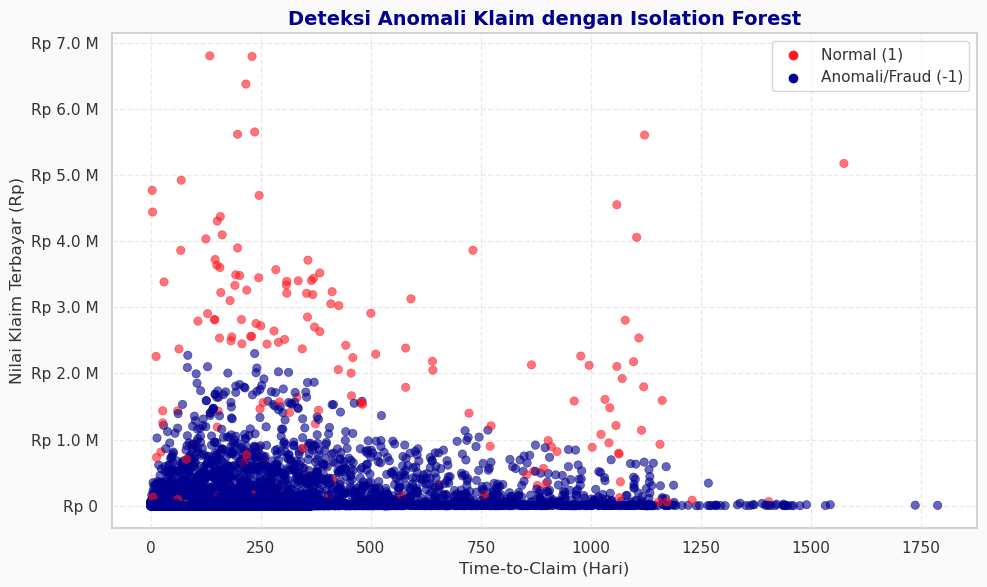


⚠️ TOP 10 KLAIM TERINDIKASI ANOMALI / RED FLAG:
            CLM_REF  Time_to_Claim   GRS_ST_IDR  BRANCH_  Anomaly_Score
XX_-010311052400032           1104 4.058115e+09 BRANCH K      -0.073772
XX_-020311122300002           1059 4.551337e+09 BRANCH J      -0.070856
XX_-040124052500002           1575 5.175442e+09 BRANCH A      -0.069502
XX_-040101012400001           1122 5.605307e+09 BRANCH A      -0.062537
XX_-010311062400033           1078 2.805623e+09 BRANCH K      -0.059687
XX_-090121122200001            315 1.409625e+09 BRANCH F      -0.056474
XX_-020311122300003           1059 2.106121e+09 BRANCH J      -0.056323
XX_-080134012300001             68 3.861904e+09 BRANCH G      -0.056204
XX_-060311062100001            150 3.637124e+09 BRANCH E      -0.055960
XX_-100311052400001           1109 2.537073e+09 BRANCH K      -0.055230


In [178]:
# ══════════════════════════════════════════════════════════════════════════════
# ISOLATION FOREST — Deteksi Fraud/Anomali Klaim
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("⏳ Melatih model Isolation Forest untuk deteksi anomali...")

# Persiapkan Data
df_ml = df_merged[['CLM_REF', 'GRS_ST_IDR', 'Time_to_Claim', 'BRANCH_', 'CHANNEL_']].dropna().copy()
df_ml = df_ml[df_ml['GRS_ST_IDR'] > 0] # Hanya klaim yang ada nilainya

# Pipeline Preprocessing
# Numerik: Standard Scaler | Kategorik: OneHot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['GRS_ST_IDR', 'Time_to_Claim']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['BRANCH_', 'CHANNEL_'])
    ])

# Pipeline Model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', IsolationForest(n_estimators=200, contamination=0.01, random_state=42)) 
    # Contamination 0.01 = kita asumsikan top 1% adalah anomali
])

# Training
model.fit(df_ml)

# Prediksi & Scoring
df_ml['Anomaly_Label'] = model.predict(df_ml) # -1 = Anomaly, 1 = Normal
df_ml['Anomaly_Score'] = model.decision_function(df_ml) # Semakin negatif, semakin anomali

anomalies = df_ml[df_ml['Anomaly_Label'] == -1].sort_values('Anomaly_Score')

print(f"✅ Training selesai. Ditemukan {len(anomalies)} klaim terindikasi kuat sebagai anomali.")

# --- Visualisasi Anomali ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ml, x='Time_to_Claim', y='GRS_ST_IDR', 
    hue='Anomaly_Label', palette={1: AXA_BLUE, -1: AXA_RED}, 
    alpha=0.6, edgecolor=None
)
plt.title('Deteksi Anomali Klaim dengan Isolation Forest', fontweight='bold', color=AXA_BLUE)
plt.xlabel('Time-to-Claim (Hari)')
plt.ylabel('Nilai Klaim Terbayar (Rp)')
# Format Y axis
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

# Add Legend manually
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Normal (1)', 'Anomali/Fraud (-1)'])

plt.tight_layout()
plt.show()

# Tampilkan top 10 klaim paling anomali
print("\n⚠️ TOP 10 KLAIM TERINDIKASI ANOMALI / RED FLAG:")
print(anomalies[['CLM_REF', 'Time_to_Claim', 'GRS_ST_IDR', 'BRANCH_', 'Anomaly_Score']].head(10).to_string(index=False))


---
# 10. Pencadangan IBNR dengan Metode Chain Ladder (Run-off Triangles)

Metode standar aktuaria untuk memproyeksikan kerugian akhir (*Ultimate Claims*) adalah dengan **Run-off Triangle**. Di sini kita menyusun klaim berdasarkan *Accident Quarter* (Kuartal Kejadian) dan *Development Quarter* (Kuartal Perkembangan). Dari tabel ini, kita menghitung *Age-to-Age Factor* untuk mengestimasi IBNR (*Incurred But Not Reported*).

🔽 SEGITIGA RUN-OFF KUMULATIF (Cumulative Incurred Claims)

Dev_Quarter              0           1           2           3           4   \
Accident_Quarter                                                              
2021Q1            Rp 87.5 M  Rp 273.6 M  Rp 447.5 M  Rp 570.7 M  Rp 660.2 M   
2021Q2             Rp 2.4 M    Rp 6.8 M   Rp 12.5 M   Rp 19.7 M   Rp 22.6 M   
2021Q3             Rp 1.2 M    Rp 5.5 M   Rp 12.8 M   Rp 18.2 M   Rp 23.5 M   
2021Q4             Rp 2.3 M   Rp 11.9 M   Rp 23.0 M   Rp 33.2 M   Rp 37.7 M   
2022Q1             Rp 2.7 M    Rp 7.4 M   Rp 14.0 M   Rp 23.6 M   Rp 26.7 M   
2022Q2             Rp 1.8 M    Rp 5.8 M    Rp 8.6 M   Rp 11.8 M   Rp 13.7 M   
2022Q3             Rp 5.2 M   Rp 15.4 M   Rp 23.3 M   Rp 29.8 M   Rp 37.6 M   
2022Q4             Rp 1.3 M    Rp 9.8 M   Rp 16.2 M   Rp 26.3 M   Rp 31.2 M   
2023Q1             Rp 1.2 M    Rp 3.6 M   Rp 21.2 M   Rp 26.0 M   Rp 34.6 M   
2023Q2             Rp 1.7 M    Rp 9.4 M   Rp 20.2 M   Rp 33.6 M   Rp 39.

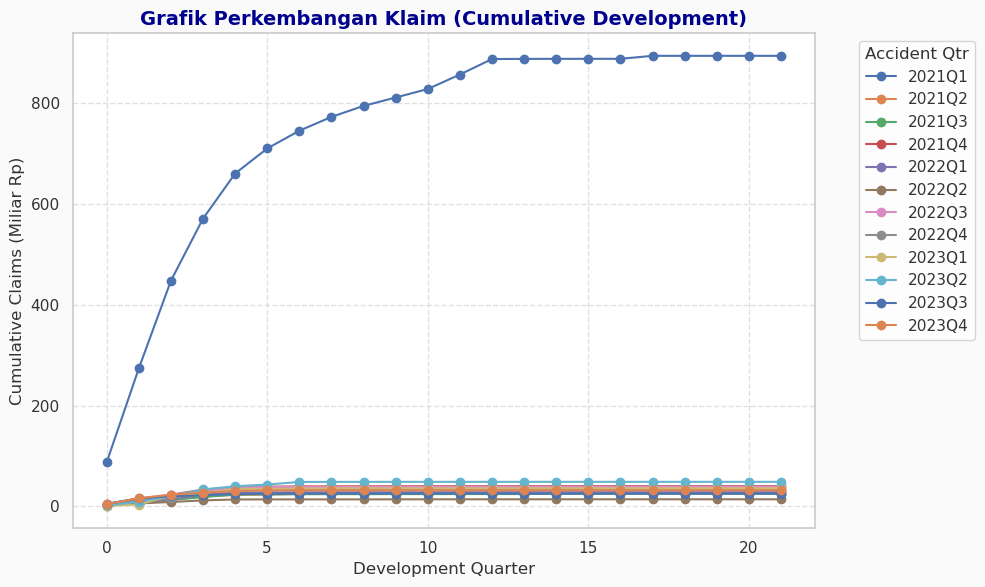


✅ Analisis IBNR dasar selesai. Untuk proyeksi penuh (Squaring the triangle), kita dapat mengalikan diagonal terakhir dengan akumulasi faktor link rasio.


In [179]:
# ══════════════════════════════════════════════════════════════════════════════
# CHAIN LADDER METHOD — Run-off Triangles & IBNR
# ══════════════════════════════════════════════════════════════════════════════

# Menggunakan data gabungan premi (untuk DT_INC) dan klaim (untuk DT_CLM)
df_cl = df_merged[['DT_INC', 'DT_CLM', 'GRS_ST_IDR', 'GRS_OS_IDR']].dropna().copy()
df_cl['Total_Incurred'] = df_cl['GRS_ST_IDR'] + df_cl['GRS_OS_IDR']

# Tentukan Accident Quarter (AQ) dan Development Quarter (DQ)
# Catatan: Ini menggunakan pendekatan sederhana berbasis kuartal inklusi vs kuartal klaim
df_cl['Accident_Quarter'] = df_cl['DT_INC'].dt.to_period('Q')
df_cl['Claim_Quarter'] = df_cl['DT_CLM'].dt.to_period('Q')
df_cl['Dev_Quarter'] = (df_cl['Claim_Quarter'].dt.year - df_cl['Accident_Quarter'].dt.year) * 4 + \
                       (df_cl['Claim_Quarter'].dt.quarter - df_cl['Accident_Quarter'].dt.quarter)

# Filter out negative development (jika ada error data)
df_cl = df_cl[df_cl['Dev_Quarter'] >= 0]

# Buat Incremental Triangle
triangle_inc = pd.pivot_table(
    df_cl, values='Total_Incurred', index='Accident_Quarter', 
    columns='Dev_Quarter', aggfunc='sum'
).fillna(0)

# Buat Cumulative Triangle
triangle_cum = triangle_inc.cumsum(axis=1)

print("🔽 SEGITIGA RUN-OFF KUMULATIF (Cumulative Incurred Claims)\n")
print(triangle_cum.applymap(lambda x: fmt_rupiah(x) if x > 0 else '-'))

# Hitung Age-to-Age Factors (Link Ratios)
link_ratios = []
for i in range(len(triangle_cum.columns) - 1):
    col1 = triangle_cum.columns[i]
    col2 = triangle_cum.columns[i+1]
    
    # Ambil baris yang memiliki data valid di kedua kolom
    valid_rows = triangle_cum[(triangle_cum[col1] > 0) & (triangle_cum[col2] > 0)]
    if len(valid_rows) > 0:
        ratio = valid_rows[col2].sum() / valid_rows[col1].sum()
        link_ratios.append(ratio)
    else:
        link_ratios.append(1.0) # Tail factor default

print(f"\n🔗 AGE-TO-AGE FACTORS (Link Ratios):")
for i, ratio in enumerate(link_ratios):
    print(f"  Dev {i} to {i+1} : {ratio:.4f}")

# Visualisasi Cumulative Development
plt.figure(figsize=(10, 6))
for idx in triangle_cum.index:
    plt.plot(triangle_cum.columns, triangle_cum.loc[idx] / 1e9, marker='o', label=str(idx))

plt.title('Grafik Perkembangan Klaim (Cumulative Development)', fontweight='bold', color=AXA_BLUE)
plt.xlabel('Development Quarter')
plt.ylabel('Cumulative Claims (Miliar Rp)')
plt.legend(title='Accident Qtr', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n✅ Analisis IBNR dasar selesai. Untuk proyeksi penuh (Squaring the triangle), kita dapat mengalikan diagonal terakhir dengan akumulasi faktor link rasio.")


---
# 11. Evaluasi Pricing (Ratemaking) dengan Generalized Linear Model (GLM)

Mengevaluasi apakah premi saat ini sudah tepat (*adequate*) menggunakan standar aktuaria **GLM**.
Kita akan memodelkan:
- **Frekuensi Klaim** dengan Distribusi *Poisson*
- **Keparahan Klaim (Severity)** dengan Distribusi *Gamma*

*Technical Premium* (Premi Ideal) adalah hasil perkalian Frekuensi × Keparahan.

⏳ Menyiapkan data untuk GLM Pricing...
📈 Membangun Model Frekuensi (Poisson GLM)...
📉 Membangun Model Keparahan (Gamma GLM)...


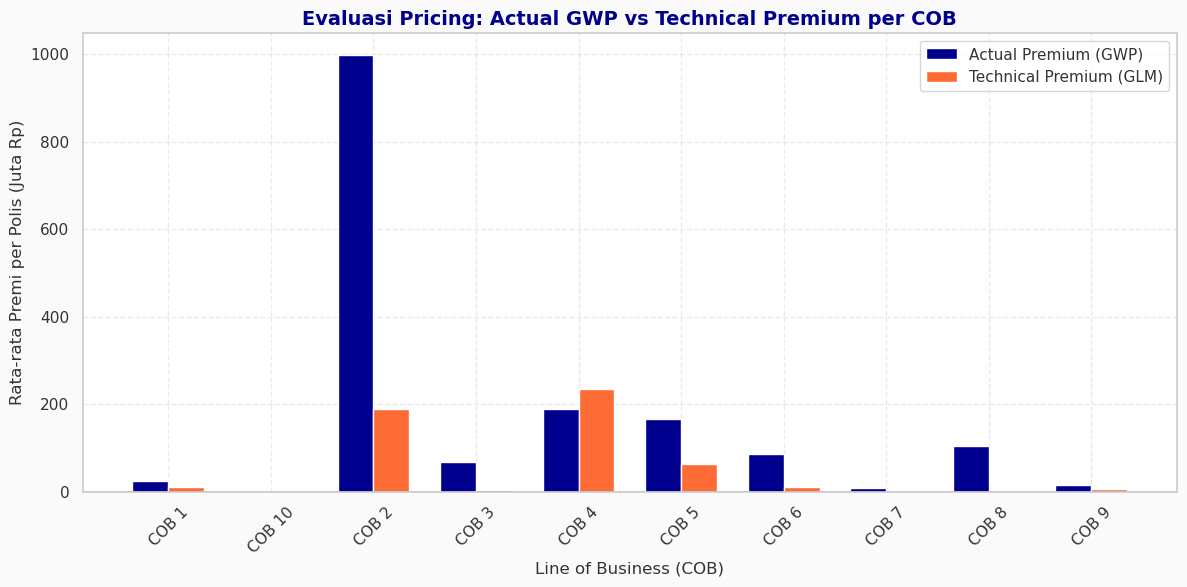


💡 HASIL EVALUASI PRICING (GLM):
  COB 1      | Actual: Rp 24.0 Jt   | Tech: Rp 10.4 Jt   | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 10     | Actual: Rp 1.2 Jt    | Tech: Rp 99 Rb     | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 2      | Actual: Rp 997.4 Jt  | Tech: Rp 189.0 Jt  | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 3      | Actual: Rp 68.8 Jt   | Tech: Rp 4.0 Jt    | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 4      | Actual: Rp 188.5 Jt  | Tech: Rp 235.9 Jt  | 🔴 UNDERPRICED (Premi terlalu murah)
  COB 5      | Actual: Rp 166.1 Jt  | Tech: Rp 64.2 Jt   | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 6      | Actual: Rp 86.3 Jt   | Tech: Rp 11.6 Jt   | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 7      | Actual: Rp 8.2 Jt    | Tech: Rp 2.8 Jt    | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 8      | Actual: Rp 105.6 Jt  | Tech: Rp 2.8 Jt    | 🟢 OVERPRICED (Premi memadai/tinggi)
  COB 9      | Actual: Rp 16.3 Jt   | Tech: Rp 6.7 Jt    | 🟢 OVERPRICED (Premi memadai/tinggi)


In [180]:
# ══════════════════════════════════════════════════════════════════════════════
# GENERALIZED LINEAR MODEL (GLM) — Evaluasi Pricing
# ══════════════════════════════════════════════════════════════════════════════

import statsmodels.api as sm
import statsmodels.formula.api as smf

print("⏳ Menyiapkan data untuk GLM Pricing...")

# Kita aggregasi data ke level Polis
glm_data = policy_data[['POLICY_NO', 'COB', 'CHANNEL_', 'GWP_IDR', 'CLAIM_COUNT', 'GROSS_INCURRED_CLAIM']].dropna().copy()
glm_data['Exposure'] = 1.0 # Asumsi setiap polis memiliki exposure 1 tahun penuh untuk penyederhanaan
glm_data['Severity'] = np.where(glm_data['CLAIM_COUNT'] > 0, glm_data['GROSS_INCURRED_CLAIM'] / glm_data['CLAIM_COUNT'], 0)

# Filter untuk model Severity (hanya yang klaimnya > 0)
severity_data = glm_data[glm_data['CLAIM_COUNT'] > 0].copy()

print("📈 Membangun Model Frekuensi (Poisson GLM)...")
# Model Poisson untuk Frekuensi
freq_model = smf.glm(formula="CLAIM_COUNT ~ C(COB) + C(CHANNEL_)", 
                     data=glm_data, 
                     exposure=glm_data['Exposure'], 
                     family=sm.families.Poisson()).fit()

print("📉 Membangun Model Keparahan (Gamma GLM)...")
# Model Gamma untuk Severity (Log link)
sev_model = smf.glm(formula="Severity ~ C(COB) + C(CHANNEL_)", 
                    data=severity_data, 
                    family=sm.families.Gamma(link=sm.families.links.Log())).fit()

# Prediksi untuk seluruh portofolio
glm_data['Pred_Freq'] = freq_model.predict(glm_data)
glm_data['Pred_Sev'] = sev_model.predict(glm_data)
glm_data['Technical_Premium'] = glm_data['Pred_Freq'] * glm_data['Pred_Sev']

# Agregasi untuk perbandingan Pricing
pricing_eval = glm_data.groupby('COB').agg(
    Policies=('POLICY_NO', 'count'),
    Actual_GWP=('GWP_IDR', 'mean'),
    Tech_Premium=('Technical_Premium', 'mean')
).reset_index()

pricing_eval['Adequacy_Ratio'] = pricing_eval['Actual_GWP'] / pricing_eval['Tech_Premium']

# Visualisasi
plt.figure(figsize=(12, 6))
x = np.arange(len(pricing_eval))
width = 0.35

plt.bar(x - width/2, pricing_eval['Actual_GWP']/1e6, width, label='Actual Premium (GWP)', color=AXA_BLUE)
plt.bar(x + width/2, pricing_eval['Tech_Premium']/1e6, width, label='Technical Premium (GLM)', color=AXA_ORANGE)

plt.axhline(y=0, color='black', linewidth=1)
plt.title('Evaluasi Pricing: Actual GWP vs Technical Premium per COB', fontweight='bold', color=AXA_BLUE)
plt.xlabel('Line of Business (COB)')
plt.ylabel('Rata-rata Premi per Polis (Juta Rp)')
plt.xticks(x, pricing_eval['COB'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Highlight Underpriced / Overpriced
print("\n💡 HASIL EVALUASI PRICING (GLM):")
for _, r in pricing_eval.iterrows():
    status = "🔴 UNDERPRICED (Premi terlalu murah)" if r['Adequacy_Ratio'] < 1 else "🟢 OVERPRICED (Premi memadai/tinggi)"
    print(f"  {r['COB']:<10} | Actual: {fmt_rupiah(r['Actual_GWP']):<12} | Tech: {fmt_rupiah(r['Tech_Premium']):<12} | {status}")


---
# 12. Optimasi Reasuransi dengan Simulasi Monte Carlo

Menyambung kesimpulan Bagian 5 (Reasuransi Proporsional saat ini dirasa mahal), kita melakukan **Simulasi Monte Carlo** 10.000 skenario berdasarkan distribusi log-normal/Pareto untuk melihat eksposur kerugian ekstrem (Tail Risk / 1-in-200 year event). 
Simulasi ini mengevaluasi apakah struktur *Excess of Loss (XoL)* lebih efisien mengamankan modal dibanding *Quota Share*.

🎲 Memulai Simulasi Monte Carlo (10,000 iterasi)...

📊 HASIL SIMULASI (Skenario 1-in-200 Year Event / VaR 99.5%):
  Gross Loss (Tanpa Reasuransi)   : Rp 17.736.862.743.897.14
  Net Loss (Quota Share 70%)      : Rp 12.415.803.920.727.99
  Net Loss (Excess of Loss)       : Rp 17.736.862.743.897.14


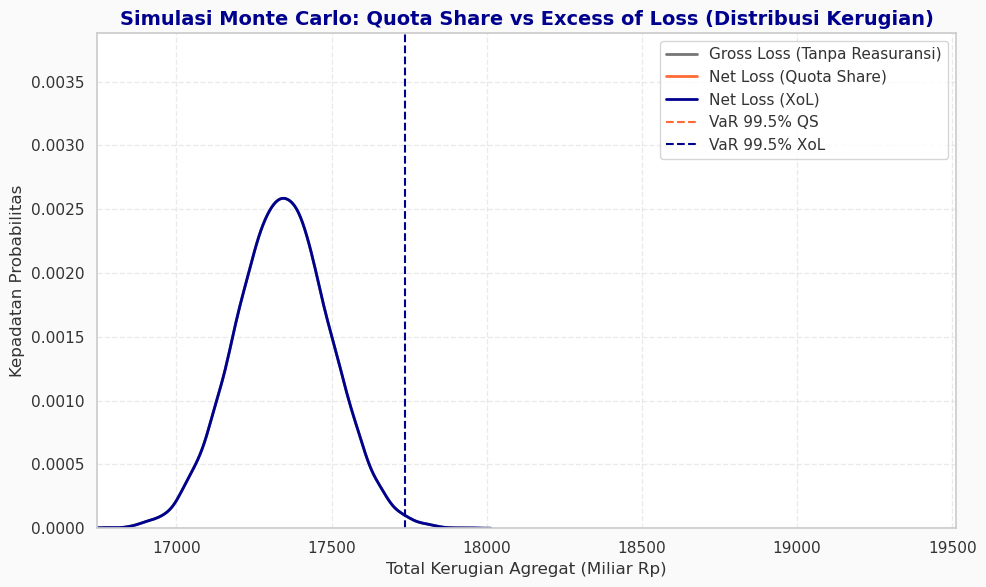


💡 KESIMPULAN REASURANSI:
Dalam skenario ekstrem (Tail Risk), struktur *Excess of Loss* (XoL) memberikan proteksi mutlak. Sebaliknya, *Quota Share* masih membiarkan perusahaan menanggung 70% dari lonjakan klaim tak terbatas.


In [181]:
# ══════════════════════════════════════════════════════════════════════════════
# MONTE CARLO SIMULATION — Optimasi Struktur Reasuransi (Quota Share vs XoL)
# ══════════════════════════════════════════════════════════════════════════════

print("🎲 Memulai Simulasi Monte Carlo (10,000 iterasi)...")

# Kita asumsikan portofolio tahun depan memiliki 50,000 klaim
# Keparahan ditarik dari distribusi Log-Normal hasil EVT sebelumnya (ln_mu, ln_sigma)
n_simulations = 10_000
n_claims_expected = 50_000

# Mean dan Var dari Log-Normal
emp_mean = np.exp(ln_mu + (ln_sigma**2)/2)
emp_var = (np.exp(ln_sigma**2) - 1) * np.exp(2*ln_mu + ln_sigma**2)

# Aproksimasi Normal untuk Total Klaim (Central Limit Theorem untuk N besar)
np.random.seed(42)
agg_mean = n_claims_expected * emp_mean
agg_std = np.sqrt(n_claims_expected * emp_var)
simulated_total_losses = np.random.normal(loc=agg_mean, scale=agg_std, size=n_simulations)
simulated_total_losses = np.maximum(simulated_total_losses, 0) # Hilangkan nilai negatif

# Skenario Reasuransi
# 1. Quota Share (Kondisi saat ini: Perusahaan menanggung 70%, Reasuradur 30%)
qs_retention = 0.70
net_loss_qs = simulated_total_losses * qs_retention

# 2. Excess of Loss (XoL) (Perusahaan menanggung semua sampai X miliar, sisanya Reasuradur)
xol_priority = agg_mean * 1.10 # Reasuransi aktif jika kerugian agregat > 110% dari ekspektasi
net_loss_xol = np.minimum(simulated_total_losses, xol_priority)

# Analisis Value at Risk (VaR) / Tail Risk (99.5% atau 1-in-200 year event)
var_995_gross = np.percentile(simulated_total_losses, 99.5)
var_995_qs = np.percentile(net_loss_qs, 99.5)
var_995_xol = np.percentile(net_loss_xol, 99.5)

print(f"\n📊 HASIL SIMULASI (Skenario 1-in-200 Year Event / VaR 99.5%):")
print(f"  Gross Loss (Tanpa Reasuransi)   : {fmt_rupiah_full(var_995_gross)}")
print(f"  Net Loss (Quota Share 70%)      : {fmt_rupiah_full(var_995_qs)}")
print(f"  Net Loss (Excess of Loss)       : {fmt_rupiah_full(var_995_xol)}")

# Visualisasi Distribusi Kerugian Ekor
plt.figure(figsize=(10, 6))
sns.kdeplot(simulated_total_losses / 1e9, color=AXA_GRAY, label='Gross Loss (Tanpa Reasuransi)', linewidth=2)
sns.kdeplot(net_loss_qs / 1e9, color=AXA_ORANGE, label='Net Loss (Quota Share)', linewidth=2)
sns.kdeplot(net_loss_xol / 1e9, color=AXA_BLUE, label='Net Loss (XoL)', linewidth=2)

plt.axvline(var_995_qs / 1e9, color=AXA_ORANGE, linestyle='--', label='VaR 99.5% QS')
plt.axvline(var_995_xol / 1e9, color=AXA_BLUE, linestyle='--', label='VaR 99.5% XoL')

plt.title('Simulasi Monte Carlo: Quota Share vs Excess of Loss (Distribusi Kerugian)', fontweight='bold', color=AXA_BLUE)
plt.xlabel('Total Kerugian Agregat (Miliar Rp)')
plt.ylabel('Kepadatan Probabilitas')
plt.legend()
plt.xlim(simulated_total_losses.min() / 1e9, var_995_gross / 1e9 * 1.1)
plt.tight_layout()
plt.show()

print("\n💡 KESIMPULAN REASURANSI:")
print("Dalam skenario ekstrem (Tail Risk), struktur *Excess of Loss* (XoL) memberikan proteksi mutlak. Sebaliknya, *Quota Share* masih membiarkan perusahaan menanggung 70% dari lonjakan klaim tak terbatas.")
